In [5]:
import pandas as pd

In [1]:
model='llama-3.1-70B'
# model= "llama-3.3-70b-versatile"
temperature='0.7'
dollar='0'
mode='csv'

In [2]:
def extract_choice(text, valid=("A", "B")):
    words = str(text).upper().replace(".", " ").split()
    one_letter_words = [w for w in words if w in valid]

    # If response mentions more than one valid option, treat as None
    if len(set(one_letter_words)) == 1:
        return one_letter_words[0]
    return None


def get_pct_most_exp_option(template,model,temperature='0',dollar='20',mode='csv'):
    df=pd.read_parquet(f'../results/{model}/{template}_{mode}_{model}_{temperature}_{dollar}.parquet')
    if template=='flight':
        exp="B"
    else:
        exp="A"
    run_cols = [col for col in df.columns if col.startswith("output_run")] 
    for col in run_cols:
        df[col + "_choice"] = df[col].apply(lambda x: extract_choice(x, valid=("A","B")))

    df["exp_count"] = (df[[c + "_choice" for c in run_cols]] == exp).sum(axis=1)
    df["exp_percentage"] = df["exp_count"] / len(run_cols)
    return df

    

In [3]:
#for the early groq experiments
# def get_pct_most_exp_option(template,model,temperature='0',dollar='20',mode='csv'):
#     df1=pd.read_parquet(f'../results/{template}_{mode}_{model}_{temperature}_{dollar}_run1.parquet')
#     df2=pd.read_parquet(f'../results/{template}_{mode}_{model}_{temperature}_{dollar}_run2.parquet')
#     df3=pd.read_parquet(f'../results/{template}_{mode}_{model}_{temperature}_{dollar}_run3.parquet')
#     df4=pd.read_parquet(f'../results/{template}_{mode}_{model}_{temperature}_{dollar}_run4.parquet')
#     df5=pd.read_parquet(f'../results/{template}_{mode}_{model}_{temperature}_{dollar}_run5.parquet')
#     df_merged=pd.concat([df1,df2,df3,df4,df5])
#     if template=='flight':
#         return df_merged.groupby("nationality")["choice"].apply(lambda x: (x.eq("B").mean())).reset_index(name="percentage_exp")
#     else:
#         return df_merged.groupby("nationality")["choice"].apply(lambda x: (x.eq("A").mean())).reset_index(name="percentage_exp")
    

In [4]:
exp_flight=get_pct_most_exp_option('flight',model,temperature,dollar,mode)
exp_hotel=get_pct_most_exp_option('hotel',model,temperature,dollar,mode)
exp_transp=get_pct_most_exp_option('transportation',model,temperature,dollar,mode)
exp_flight_4=get_pct_most_exp_option('flight',model,temperature,'4',mode)
exp_hotel_4=get_pct_most_exp_option('hotel',model,temperature,'4',mode)
exp_transp_4=get_pct_most_exp_option('transportation',model,temperature,'4',mode)

NameError: name 'pd' is not defined

In [158]:
print(exp_flight['exp_percentage'].corr(exp_flight_4['exp_percentage']))
print(exp_hotel['exp_percentage'].corr(exp_hotel_4['exp_percentage']))
print(exp_transp['exp_percentage'].corr(exp_transp_4['exp_percentage']))

0.37353897163161537
1.0
0.506447310967726


In [168]:
exp_hotel[['exp_percentage','dollars']].groupby('dollars').mean()

,exp_percentage
dollars,
5,0.6
10,0.6
20,0.6
50,0.6


In [169]:
exp_hotel_4[['exp_percentage','dollars']].groupby('dollars').mean()

,exp_percentage
dollars,
4,0.6
9,0.6
19,0.6
49,0.6


In [170]:
exp_total=pd.concat([exp_flight,exp_hotel,exp_transp])
result = (exp_total.groupby("nationality")   # group per country
      ["exp_percentage"]
      .mean()                   # average across all rows per country
      .reset_index(name="mean_percentage")
)
exp_total_4=pd.concat([exp_flight_4,exp_hotel_4,exp_transp_4])
result_4 = (exp_total_4.groupby("nationality")   # group per country
      ["exp_percentage"]
      .mean()                   # average across all rows per country
      .reset_index(name="mean_percentage")
)

In [171]:
result_dict=result.set_index('nationality').to_dict()['mean_percentage']
result_dict_4=result_4.set_index('nationality').to_dict()['mean_percentage']

In [53]:
import pandas as pd
import plotly.express as px
import json

def plot_world_scores_countrynames(country_scores: dict[str, float],
                      title: str = "Scores by Country",
                      out_html: str | None = None):
    """
    country_scores: {"Belgium": 0.81, "United States": 0.73, ...}
    - Uses country *names* directly (Plotly locationmode='country names').
    - Saves an interactive HTML file if out_html is provided.
    """
    df = pd.DataFrame([
        {"country": k, "score": v} for k, v in country_scores.items()
    ])
    vmin, vmax = df["score"].min(), df["score"].max()
    fig = px.choropleth(
        df,
        locations="country",
        locationmode="country names",  # <- accepts country names like "Belgium"
        color="score",
        color_continuous_scale="Viridis",
        range_color=(0,1),
        title=title,
        labels={"score": "Score"},
        projection="natural earth",
    )
    fig.update_layout(margin=dict(l=0, r=0, t=60, b=0))
    if out_html:
        fig.write_html(out_html, include_plotlyjs="cdn")
    return fig

def plot_world_scores_countrycodes(country_scores: dict[str, float],
                                   geojson_path="../countries.geojson",
                      title: str = "Scores by Country",
                      out_html: str | None = None):
    """
    country_scores: {"Belgium": 0.81, "United States": 0.73, ...}
    - Uses country *names* directly (Plotly locationmode='country names').
    - Saves an interactive HTML file if out_html is provided.
    """
    df = pd.DataFrame([
        {"iso3": k, "score": v} for k, v in country_scores.items()
    ])

    with open("../countries.geojson", "r", encoding="utf-8") as f:
        geojson = json.load(f)
    
    code_map = {"SSD": "SDS"}  # GeoJSON expects SDS
    df["geo_code"] = df["iso3"].replace(code_map)

    vmin, vmax = df["score"].min(), df["score"].max()
    fig = px.choropleth(
        df,
        locations="iso3",
        locationmode="ISO-3",  # <- accepts country names like "Belgium"
        color="score",
        color_continuous_scale="Viridis",
        range_color=(vmin,vmax),
        title=title,
        labels={"score": "Score"},
        projection="natural earth",
    )
    fig.update_layout(margin=dict(l=0, r=0, t=60, b=0))
    if out_html:
        fig.write_html(out_html, include_plotlyjs="cdn")
    return fig

### Overall probability of choosing the most expensive option for the different nationalities
seems like especially in Europe there is a higher likelihood of saying yes, but also a bit in some other countries, even in Africa (Sudan, Ethiopia, Kenya)

In [173]:
fig = plot_world_scores(result_dict, title="Percentage choosing most expensive option", out_html="world_scores.html")
fig.show()  # opens an interactive map

C:\Users\u0146965\AppData\Local\Temp\ipykernel_25936\1526259375.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [174]:
fig = plot_world_scores(result_dict_4, title="Percentage choosing most expensive option", out_html="world_scores.html")
fig.show()  # opens an interactive map

C:\Users\u0146965\AppData\Local\Temp\ipykernel_25936\1526259375.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### Flight

In [136]:
result_dict=exp_flight.set_index('nationality').to_dict()['exp_percentage']
fig = plot_world_scores(result_dict, title="Percentage choosing most expensive flight", out_html="world_scores.html")
fig.show()  # opens an interactive map

C:\Users\u0146965\AppData\Local\Temp\ipykernel_25936\1526259375.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [175]:
result_dict_4=exp_flight_4.set_index('nationality').to_dict()['exp_percentage']
fig = plot_world_scores(result_dict_4, title="Percentage choosing most expensive flight", out_html="world_scores.html")
fig.show()  # opens an interactive map

C:\Users\u0146965\AppData\Local\Temp\ipykernel_25936\1526259375.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### Hotel

In [115]:
result_dict=exp_hotel.set_index('nationality').to_dict()['exp_percentage']
fig = plot_world_scores(result_dict, title="Percentage choosing most expensive hotel", out_html="world_scores.html")
# fig.write_image("../results/figures/hotel_preferences.pdf")
fig.show()  # opens an interactive map


C:\Users\u0146965\AppData\Local\Temp\ipykernel_25936\1526259375.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### Transportation

In [116]:
result_dict=exp_transp.set_index('nationality').to_dict()['exp_percentage']
fig = plot_world_scores(result_dict, title="Percentage choosing most expensive transp", out_html="world_scores.html")
fig.show()  # opens an interactive map

C:\Users\u0146965\AppData\Local\Temp\ipykernel_25936\1526259375.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [176]:
result_dict=exp_transp_4.set_index('nationality').to_dict()['exp_percentage']
fig = plot_world_scores(result_dict, title="Percentage choosing most expensive transp", out_html="world_scores.html")
fig.show()  # opens an interactive map

C:\Users\u0146965\AppData\Local\Temp\ipykernel_25936\1526259375.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### Flight llama 70B

In [ ]:
result_dict=exp_flight.set_index('nationality').to_dict()['percentage_exp']
fig = plot_world_scores(result_dict, title="Percentage choosing most expensive flight", out_html="world_scores.html")
fig.show()  # opens an  interactive map

C:\Users\u0146965\AppData\Local\Temp\ipykernel_23016\1526259375.py:15: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


### Hotel llama 70B

In [27]:
result_dict=exp_hotel.set_index('nationality').to_dict()['percentage_exp']
fig = plot_world_scores(result_dict, title="Percentage choosing most expensive hotel", out_html="world_scores.html")
fig.show()  # opens an  interactive map

C:\Users\u0146965\AppData\Local\Temp\ipykernel_23016\1526259375.py:15: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



# Analysis of the general templates

In [181]:
import pandas as pd

In [375]:
# model='gpt-5-mini'
model=  "qwen2.5-7B"#qwen2.5-7B"#'llama-3.1-8B'
temperature='0.0'
dollar='0'
mode='csv'
template='hotel_room'#general_template#general_nonationality_no_history
runs='1'
model_name=model

In [376]:
df=pd.read_parquet(f'../results/only travel/{model}/{template}_{mode}_{model}_{temperature}_runs_{runs}.parquet')
# df=pd.read_parquet(f'../results/only travel/{model}/{template}_{mode}_{model}_{temperature}.parquet')
# df=pd.read_parquet(f'../results/{model}/full_batch_results_{template}_{model}.parquet')

In [377]:
test=df.iloc[::2]

In [380]:
test.loc[test['amount_info']=='no_info']

,nationality,application,dilemma_type,scenario_a,scenario_b,amount_info,prev_info,output_run0,input
0,none,hotel_room,0,The user books the hotel room on the 18th floo...,The user books the hotel room on the 26th floo...,no_info,,B,"[{""role"": ""system"", ""content"": ""You are a smar..."
2,none,hotel_room,0,The user books the hotel room on the 18th floo...,The user books the hotel room on the 26th floo...,no_info,,B,"[{""role"": ""system"", ""content"": ""You are a smar..."
84,none,hotel_room,1,The user books the hotel room on the 10th floo...,The user books the hotel room on the 26th floo...,no_info,,B,"[{""role"": ""system"", ""content"": ""You are a smar..."
86,none,hotel_room,1,The user books the hotel room on the 10th floo...,The user books the hotel room on the 26th floo...,no_info,,B,"[{""role"": ""system"", ""content"": ""You are a smar..."
168,none,hotel_room,2,The user books the hotel room on the 26th floo...,The user books the hotel room on the 26th floo...,no_info,,B,"[{""role"": ""system"", ""content"": ""You are a smar..."
...,...,...,...,...,...,...,...,...,...
19910,none,hotel_room,237,The user books the hotel room on the 10th floo...,The user books the hotel room on the 18th floo...,no_info,,A,"[{""role"": ""system"", ""content"": ""You are a smar..."
19992,none,hotel_room,238,The user books the hotel room on the 18th floo...,The user books the hotel room on the 18th floo...,no_info,,B,"[{""role"": ""system"", ""content"": ""You are a smar..."
19994,none,hotel_room,238,The user books the hotel room on the 18th floo...,The user books the hotel room on the 18th floo...,no_info,,B,"[{""role"": ""system"", ""content"": ""You are a smar..."
20076,none,hotel_room,239,The user books the hotel room on the 26th floo...,The user books the hotel room on the 26th floo...,no_info,,B,"[{""role"": ""system"", ""content"": ""You are a smar..."


In [226]:
df['amount_info'].unique()

array(['no_info', 'one_example_randomcheap', 'one_example_randomexp',
       'one_example_clearcheap', 'one_example_clearexp',
       'three_examples_cheap', 'three_examples_exp', 'three_examples_mix',
       'persona_business', 'persona_student',
       'persona_business_and_exp_examples',
       'persona_student_and_cheap_examples',
       'one_example_randomcheap_USD', 'one_example_randomexp_USD',
       'one_example_clearcheap_USD', 'one_example_clearexp_USD',
       'three_examples_cheap_USD', 'three_examples_exp_USD',
       'three_examples_mix_USD', 'persona_business_and_exp_examples_USD',
       'persona_student_and_cheap_examples_USD'], dtype=object)

In [227]:
df_to_merge=pd.read_parquet('../vars/hotel_room_dilemmas.parquet')

In [228]:
def extract_choice(text, valid=("A", "B")):
    words = str(text).upper().replace(".", " ").split()
    one_letter_words = [w for w in words if w in valid]
    none=('I can not',"I can't", 'I cannot')

    # If response mentions more than one valid option, treat as None
    if any(phrase in text for phrase in none):
        print(text)
        return 'None'
    elif len(set(one_letter_words)) == 1:
        return one_letter_words[0]
    return 'None'


def get_pct_most_exp_option(template,model,temperature='0',mode='csv',df=None,mode_calc='mean'):
    if df.empty:
        df=pd.read_parquet(f'../results/{model}/{template}_{mode}_{model}_{temperature}.parquet')
    run_cols = [col for col in df.columns if col.startswith("output_run")] 
    for col in run_cols:
        df[col + "_choice"] = df[col].apply(lambda x: extract_choice(x, valid=("A","B")))

    choice_cols = [c + "_choice" for c in run_cols]
    if mode_calc=='mean':
        df["exp_count"] = df[choice_cols].eq(df["exp_option"], axis=0).sum(axis=1)
        df["none_count"] = (df[choice_cols] == 'None').sum(axis=1)
        df["exp_percentage"] = df["exp_count"] / len(run_cols)
        df["none_percentage"] = df["none_count"] / len(run_cols)
    elif mode_calc=='std':
        #ToDO implement stddev function for none
        df['std_dev']=df[choice_cols].replace({'A':0,'B':1}).std(axis=1)
    return df

def reshape_for_mixed_logit(template,model,temperature='0',mode='csv',df=None,mode_calc='mean'):
    if df.empty:
        df=pd.read_parquet(f'../results/{model}/{template}_{mode}_{model}_{temperature}.parquet')
    run_cols = [col for col in df.columns if col.startswith("output_run")] 
    print(df.columns)
    for col in run_cols:
        df[col + "_choice"] = df[col].apply(lambda x: extract_choice(x, valid=("A","B")))

    choice_cols = [c + "_choice" for c in run_cols]

    return df

    

In [229]:
df=reshape_for_mixed_logit(template, model,temperature,mode,df=df)

Index(['nationality', 'application', 'dilemma_type', 'scenario_a',
       'scenario_b', 'amount_info', 'prev_info', 'input', 'output_run0',
       'output_run1', 'output_run2', 'output_run3', 'output_run4'],
      dtype='object')


In [230]:
run_cols = [col for col in df.columns if col.startswith("output_run")]
choice_cols = [c for c in run_cols if 'choice' in c]
output_runs_final=set(run_cols).symmetric_difference(choice_cols)

In [231]:
df_long = df.melt(
    id_vars=[col for col in df.columns if col not in run_cols],  # all other variables
    value_vars=choice_cols,                                         # choice columns only
    var_name="run_variable",
    value_name="output_choice"
)
#add unique id
df_long['unique_id']=df_long.index
df_long=df_long.rename(columns={'scenario_a':'A','scenario_b':'B'})
df_long=df_long.melt(id_vars=[col for col in df_long.columns if col not in ['A','B']],value_vars=['A','B'],var_name='Scenario', value_name='scenario_prompt')
df_long=df_long.sort_values(['unique_id','Scenario'])

In [243]:
df_long['scenario_prompt'].unique()

array(['The user books the hotel room on the 10th floor with a view on the city. The user gets access to the hotel club, which includes extra services such as breakfast and evening cocktails served in the panoramic restaurant. The free mini bar includes soft drinks, snacks and a smartphone is available (with free voice + data). The booking is non-refundable and the room costs HK$ 3200 per night.',
       'The user books the hotel room on the 10th floor with a view on the harbour. The user does not get access to the hotel club, which includes extra services such as breakfast and evening cocktails served in the panoramic restaurant. The free mini bar includes soft drinks, snacks and a smartphone is available (with free voice + data). The booking is non-refundable and the room costs HK$ 2800 per night.',
       'The user books the hotel room on the 10th floor with a view on the city. The user gets access to the hotel club, which includes extra services such as breakfast and evening cockta

In [261]:
scen_prompts=df_to_merge.drop(['dilemma_id'],axis=1).drop_duplicates()['scenario_prompt'].to_list()

In [247]:
'The user books the hotel room on the 10th floor with a view on the harbour. The user does not get access to the hotel club, which includes extra services such as breakfast and evening cocktails served in the panoramic restaurant. The free mini bar includes soft drinks, snacks and a smartphone is available (with free voice + data). The booking is non-refundable and the room costs HK$ 2800 per night.',


True

In [249]:
len(df_long)

25200

In [252]:
test=pd.merge(df_long,df_to_merge.drop(['dilemma_id'],axis=1).drop_duplicates(),on='scenario_prompt',how='left').dropna()

In [259]:
to_check=df_long.loc[df_long['dilemma_type']==3]['scenario_prompt'][168]

In [266]:
df_long=df_long.fillna('')

In [202]:
df_full=pd.merge(df_long,df_to_merge.drop(['dilemma_id'],axis=1).drop_duplicates(),on='scenario_prompt',how='left').dropna()
df_USD_to_merge=df_to_merge.drop(['dilemma_id','scenario_prompt'],axis=1)
df_full_USD=pd.merge(df_long,df_USD_to_merge.drop_duplicates().rename(columns={'scenario_prompt_USD':'scenario_prompt'}),on='scenario_prompt', how='left').dropna()

In [165]:
#check that everything is kept
#,right_on='scenario_prompt_USD',left_on='scenario_prompt'
len(df_full)+len(df_full_USD)==len(df_long)

False

In [166]:
def map_values(df_full,HK='yes'):
    df_full['view']=df_full['view'].map({'city':0,'harbour':1})
    df_full['floor']=df_full['floor'].map({'10th':10,'18th':18,'26th':26})
    df_full['access_club']=df_full['access_club'].map({'no':0,'yes':1})
    df_full['free_mini_bar']=df_full['free_mini_bar'].map({'soft drinks, snacks':0,'soft drinks, snacks, wine & beer':1})
    df_full['guest_smartphone']=df_full['guest_smartphone'].map({'not available':0,'available (with free voice + data)':1})
    df_full['cancellation']=df_full['cancellation'].map({'non-refundable':0,'refundable (up to 24 h. prior)':1})
    df_full['price_per_night']=df_full['price_per_night'].map({'HK$ 1600':1600,'HK$ 2000':2000,'HK$ 2400':2400,'HK$ 2800':2800,'HK$ 3200':3200})
    df_full['price_per_night_USD']=df_full['price_per_night_USD'].map({'US$ 312.0':312,'US$ 260.0':260,'US$ 208.0':208,'US$ 364.0':364,'US$ 416.0':416})
    # df_full['output_choice']=df_full['output_choice'].map({'A':0,'B':1})
    return df_full

In [167]:
df_full_USD=map_values(df_full_USD,'no')
df_full=map_values(df_full)

In [168]:
df_full_no_info=df_full.loc[df_full['amount_info']=='no_info']
df_full_one_clear_cheap=df_full.loc[df_full['amount_info']=='one_example_clearcheap']
df_full_one_random_cheap=df_full.loc[df_full['amount_info']=='one_example_randomcheap']
df_full_one_random_exp=df_full.loc[df_full['amount_info']=='one_example_randomexp']
df_full_one_clear_exp=df_full.loc[df_full['amount_info']=='one_example_clearexp']
df_full_three_cheap=df_full.loc[df_full['amount_info']=='three_examples_cheap']
df_full_three_exp=df_full.loc[df_full['amount_info']=='three_examples_exp']
df_full_three_mix=df_full.loc[df_full['amount_info']=='three_examples_mix']
df_full_persona_business=df_full.loc[df_full['amount_info']=='persona_business']
df_full_persona_student=df_full.loc[df_full['amount_info']=='persona_student']
df_full_business_and_three_exp=df_full.loc[df_full['amount_info']=='persona_business_and_exp_examples']
df_full_student_and_three_cheap=df_full.loc[df_full['amount_info']=='persona_student_and_cheap_examples']
df_full_one_clear_cheap_USD=df_full.loc[df_full['amount_info']=='one_example_clearcheap_USD']
df_full_one_random_cheap_USD=df_full.loc[df_full['amount_info']=='one_example_randomcheap_USD']
df_full_one_random_exp_USD=df_full.loc[df_full['amount_info']=='one_example_randomexp_USD']
df_full_one_clear_exp_USD=df_full.loc[df_full['amount_info']=='one_example_clearexp_USD']
df_full_three_cheap_USD=df_full.loc[df_full['amount_info']=='three_examples_cheap_USD']
df_full_three_exp_USD=df_full.loc[df_full['amount_info']=='three_examples_exp_USD']
df_full_three_mix_USD=df_full.loc[df_full['amount_info']=='three_examples_mix_USD']
df_full_business_and_three_exp_USD=df_full.loc[df_full['amount_info']=='persona_business_and_exp_examples_USD']
df_full_student_and_three_cheap_USD=df_full.loc[df_full['amount_info']=='persona_student_and_cheap_examples_USD']

In [169]:
df_full_USD_no_info=df_full_USD.loc[df_full_USD['amount_info']=='no_info']
df_full_USD_one_clear_cheap=df_full_USD.loc[df_full_USD['amount_info']=='one_example_clearcheap']
df_full_USD_one_random_cheap=df_full_USD.loc[df_full_USD['amount_info']=='one_example_randomcheap']
df_full_USD_one_random_exp=df_full_USD.loc[df_full_USD['amount_info']=='one_example_randomexp']
df_full_USD_one_clear_exp=df_full_USD.loc[df_full_USD['amount_info']=='one_example_clearexp']
df_full_USD_three_cheap=df_full_USD.loc[df_full_USD['amount_info']=='three_examples_cheap']
df_full_USD_three_exp=df_full_USD.loc[df_full_USD['amount_info']=='three_examples_exp']
df_full_USD_three_mix=df_full_USD.loc[df_full_USD['amount_info']=='three_examples_mix']
df_full_USD_persona_business=df_full_USD.loc[df_full_USD['amount_info']=='persona_business']
df_full_USD_persona_student=df_full_USD.loc[df_full_USD['amount_info']=='persona_student']
df_full_USD_business_and_three_exp=df_full_USD.loc[df_full_USD['amount_info']=='persona_business_and_exp_examples']
df_full_USD_student_and_three_cheap=df_full_USD.loc[df_full_USD['amount_info']=='persona_student_and_cheap_examples']
df_full_USD_one_clear_cheap_USD=df_full_USD.loc[df_full_USD['amount_info']=='one_example_clearcheap_USD']
df_full_USD_one_random_cheap_USD=df_full_USD.loc[df_full_USD['amount_info']=='one_example_randomcheap_USD']
df_full_USD_one_random_exp_USD=df_full_USD.loc[df_full_USD['amount_info']=='one_example_randomexp_USD']
df_full_USD_one_clear_exp_USD=df_full_USD.loc[df_full_USD['amount_info']=='one_example_clearexp_USD']
df_full_USD_three_cheap_USD=df_full_USD.loc[df_full_USD['amount_info']=='three_examples_cheap_USD']
df_full_USD_three_exp_USD=df_full_USD.loc[df_full_USD['amount_info']=='three_examples_exp_USD']
df_full_USD_three_mix_USD=df_full_USD.loc[df_full_USD['amount_info']=='three_examples_mix_USD']
df_full_USD_business_and_three_exp_USD=df_full_USD.loc[df_full_USD['amount_info']=='persona_business_and_exp_examples_USD']
df_full_USD_student_and_three_cheap_USD=df_full_USD.loc[df_full_USD['amount_info']=='persona_student_and_cheap_examples_USD']

In [171]:
from xlogit import MixedLogit,MultinomialLogit
from itertools import combinations
import numpy as np
from sklearn.model_selection import train_test_split

def get_mixed_logit(df_full_no_info,panel='one'):
    varnames=['view', 'floor', 'access_club', 'free_mini_bar','guest_smartphone','cancellation','price_per_night']
    model = MixedLogit()
    if panel=='one':
        #as every model reflects same person: 
        df_full_no_info["panel_id"] = 1
    elif panel=='multiple':
        df_full_no_info["panel_id"]=df_full_no_info["unique_id"]
    model.fit(X=df_full_no_info[varnames], y=df_full_no_info['output_choice'], varnames=varnames,
            alts=df_full_no_info['Scenario'], ids=df_full_no_info['unique_id'],
            panels=df_full_no_info["panel_id"],randvars={'view': 'n','floor':'n','access_club':'n'}, n_draws=1500,
            optim_method='L-BFGS-B')
    print(model.summary())

def get_multinomial_logit(df,var_names=['view', 'floor', 'access_club', 'free_mini_bar','guest_smartphone','cancellation','price_per_night']):
    varnames=var_names
    # df['price_per_night_in_thousands']=df['price_per_night']/1000
    print(var_names)
    # dilemma_ids=df['dilemma_type'].unique()
    # train_ids, test_ids = train_test_split(
    #     dilemma_ids,
    #     test_size=0.2,
    #     random_state=42,   # fixed seed = reproducible
    #     shuffle=True
    # )
    # df_train=df.loc[df['dilemma_type'].isin(train_ids)]
    # df_test=df.loc[df['dilemma_type'].isin(test_ids)]
    model = MultinomialLogit()
    model.fit(X=df[varnames], y=df['output_choice'], varnames=varnames,
            ids=df['unique_id'], alts=df['Scenario'],num_hess=False) 
    model_null=MultinomialLogit()
    X_null = np.zeros((len(df), 0))
    model_null.fit(X=X_null, y=df['output_choice'], varnames=[],
            ids=df['unique_id'], alts=df['Scenario'],fit_intercept=True, num_hess=False) 
    acc,_,_=calculate_acc(model,df)
    
    return model,acc,model_null
def find_best_multinomial_logit(df):
    poss_varnames=['view', 'floor', 'access_club', 'free_mini_bar','guest_smartphone','cancellation','price_per_night']
    all_combinations=[]
    for r in range(1, len(poss_varnames) + 1):
        all_combinations.extend(combinations(poss_varnames, r))
    aic_scores=[]
    for varnames in all_combinations:
        print(varnames)
        # if varnames==('access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night'):
        #     break
        model=get_multinomial_logit(df,list(varnames))
        aic_scores.append(model.aic)
    index_min = np.argmin(aic_scores)
    final_var_names=list(all_combinations[index_min])
    final_model=get_multinomial_logit(df,final_var_names)
    print(final_model.summary())
    return final_model

So I am fitting the best possible multinomial model for every model based on the AIC criteria. --> determining for all possible var combinations what is needed

In [172]:
list_dfs=[df_full_no_info,df_full_one_clear_cheap,df_full_one_random_cheap,df_full_one_random_exp,df_full_one_clear_exp,df_full_three_cheap,df_full_three_exp,df_full_three_mix,df_full_persona_business,df_full_persona_student,df_full_business_and_three_exp,df_full_student_and_three_cheap,df_full_one_clear_cheap_USD,df_full_one_random_cheap_USD,df_full_one_random_exp_USD,df_full_one_clear_exp_USD,df_full_three_cheap_USD,df_full_three_exp_USD,df_full_three_mix_USD,df_full_business_and_three_exp_USD,df_full_student_and_three_cheap_USD]
list_dfs_USD_dilemma=[df_full_USD_no_info,df_full_USD_one_clear_cheap,df_full_USD_one_random_cheap,df_full_USD_one_random_exp,df_full_USD_one_clear_exp,df_full_USD_three_cheap,df_full_USD_three_exp,df_full_three_mix,df_full_USD_persona_business,df_full_USD_persona_student,df_full_USD_business_and_three_exp,df_full_USD_student_and_three_cheap,df_full_USD_one_clear_cheap_USD,df_full_USD_one_random_cheap_USD,df_full_USD_one_random_exp_USD,df_full_USD_one_clear_exp_USD,df_full_USD_three_cheap_USD,df_full_USD_three_exp_USD,df_full_USD_three_mix_USD,df_full_USD_business_and_three_exp_USD,df_full_USD_student_and_three_cheap_USD]
names=[df_['amount_info'].unique()[0] for df_ in list_dfs]

In [300]:
import pandas as pd
df_gpt_rsqrt=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\gpt-5-mini\r_sqrts.parquet')
df_qwen_rsqrt=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\qwen2.5-7B\r_sqrts.parquet')
df_llama3B_rsqrt=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\llama-3.2-3B\r_sqrts.parquet')
df_llama8B_rsqrt=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\llama-3.1-8B\r_sqrts.parquet')
df_llama70B_rsqrt=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\llama-3.3-70B\r_sqrts.parquet')

df_gpt_acc=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\gpt-5-mini\accuracies.parquet')
df_qwen_acc=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\qwen2.5-7B\accuracies.parquet')
df_llama3B_acc=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\llama-3.2-3B\accuracies.parquet')
df_llama8B_acc=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\llama-3.1-8B\accuracies.parquet')
df_llama70B_acc=pd.read_parquet(r'C:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\results\multinomial_models\llama-3.3-70B\accuracies.parquet')


In [83]:
path='../results/multinomial_models/'
model='qwen2.5-7B'
info='no_info'
df=pd.read_parquet(f'{path}/{model}/r_sqrtsfirst.parquet')

In [84]:
df

,no_info,one_example_randomcheap,one_example_randomexp,one_example_clearcheap,one_example_clearexp,three_examples_cheap,three_examples_exp,three_examples_mix,persona_business,persona_student,...,persona_student_and_cheap_examples,one_example_randomcheap_USD,one_example_randomexp_USD,one_example_clearcheap_USD,one_example_clearexp_USD,three_examples_cheap_USD,three_examples_exp_USD,three_examples_mix_USD,persona_business_and_exp_examples_USD,persona_student_and_cheap_examples_USD
HKD,0.375214,0.351236,0.427197,0.150180,0.156859,0.42378,0.429846,0.389133,0.454821,0.498073,...,0.303234,0.434297,0.378636,0.298450,0.160806,0.463821,0.569026,0.391606,0.490981,0.426073
USD,0.386726,0.490665,0.425057,0.259061,0.251070,0.42400,0.551441,0.472985,0.483153,0.612140,...,0.336006,0.362379,0.471322,0.223627,0.206988,0.441797,0.452700,0.467988,0.479805,0.395297


In [36]:
#24
df_test=pd.read_parquet('../vars/hotel_room_dilemmas.parquet')

In [9]:
import pandas as pd
df=pd.read_parquet('../results/haiku/full_batch_results_hotel_room_haiku.parquet')

In [13]:
df.loc[df['amount_info']=='no_info']['output_run0'].value_counts()

output_run0
A                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 528
B                                                                                                                                                                                                                                                                                                                                                                                     

In [339]:
model.predict()

array(['_intercept.B', 'view', 'floor', 'access_club', 'free_mini_bar',
       'guest_smartphone', 'cancellation', 'price_per_night_in_thousands'],
      dtype='<U28')

In [85]:
import joblib
path='../results/multinomial_models/'
model_name='llama-3.3-70B'
info='no_info'
model=joblib.load(f"{path}/{model_name}/multinomial_logit_model_{info}_HK_dilemmas_first.joblib")
scaler=joblib.load(f"{path}/{model_name}/standardscaler/standardscaler_{info}_HK_dilemmas_first.joblib")
model.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 13
    Function evaluations: 14
Estimation time= 0.0 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
_intercept.B           -1.9762586     0.3400641    -5.8114306      1.96e-08 ***
view                    0.5303176     0.1774834     2.9879839        0.0031 ** 
floor                   0.1122619     0.1690857     0.6639349         0.507    
access_club             1.9432579     0.3176803     6.1170234      3.84e-09 ***
free_mini_bar           0.3366881     0.1697756     1.9831363        0.0485 *  
guest_smartphone        1.3349302     0.2408561     5.5424380      7.84e-08 ***
cancellation            1.6763843     0.2831570     5.9203358       1.1e-08 ***
price_per_night        -1.1733958     0.2273433    -

In [14]:
data= """
B	3200
B	2400
B	2800
B	2400
B	1600
B	1600
B	3200
B	2000
A	2000
A	2800
A	2400
A	2400
A	2000
A	2400
B	2800
B	1600
B	2800
B	2000
B	2800
B	2800
A	1600
A	3200
A	1600
A	3200
B	2800
B	2400
A	2400
A	3200
B	2800
B	2000
A	2400
A	2800
A	2000
A	2800
A	2000
A	2800
B	2400
B	2000
B	1600
B	1600
A	2400
A	2400
B	2000
B	1600
A	1600
A	3200
A	1600
A	2800
A	1600
A	2000
B	2800
B	2000
B	2400
B	2000
A	1600
A	3200
A	3200
A	3200
B	3200
B	1600
A	2400
A	3200
A	3200
A	3200
B	2400
B	2400
B	3200
B	1600
A	1600
A	2400
A	1600
A	2000
B	3200
B	2800
A	2000
A	3200
A	2400
A	2800
B	3200
B	2400
B	2800
B	2000
B	2400
B	2000
A	1600
A	3200
B	2400
B	2000
A	2400
A	3200
A	2000
A	2400
B	2800
B	2000
B	2800
B	2400
B	2800
B	2800
B	2400
B	1600
B	3200
B	1600
B	3200
B	2000
B	3200
B	3200
B	2000
B	1600
A	2000
A	2800
A	2000
A	2400
B	2800
B	2000
A	2800
A	3200
A	1600
A	2800
A	1600
A	2400
A	2400
A	2800
A	1600
A	1600
A	2400
A	3200
A	2800
A	3200
B	2000
B	2000
A	2000
A	2400
B	2400
B	2000
B	2400
B	2000
B	3200
B	1600
A	2000
A	2800
B	3200
B	3200
A	2800
A	2800
A	1600
A	2000
B	3200
B	2000
A	1600
A	3200
B	2800
B	1600
B	2800
B	1600
B	2400
B	2400
B	2800
B	1600
A	2400
A	2400
A	1600
A	1600
B	3200
B	1600
B	2400
B	2000
B	2000
B	1600
B	2800
B	1600
A	2000
A	2800
B	2400
B	1600
A	2000
A	2400
B	1600
B	1600
A	2800
A	2800
A	2000
A	2800
A	2000
A	3200
A	2800
A	2800
A	3200
A	3200
A	1600
A	2000
B	3200
B	1600
A	2800
A	3200
A	1600
A	1600
B	2800
B	2000
A	2800
A	2800
B	2800
B	1600
A	2000
A	2800
B	3200
B	2800
B	2000
B	2000
A	1600
A	3200
A	1600
A	1600
A	1600
A	3200
B	3200
B	2400
B	2000
B	2000
A	3200
A	3200
A	2000
A	2400
B	2800
B	2400
A	1600
A	2800
A	2400
A	2800
B	3200
B	2400
B	3200
B	1600
B	3200
B	1600
B	2400
B	2000
A	1600
A	3200
A	2000
A	2800
B	2400
B	1600
A	2400
A	2800
A	2400
A	2400
A	1600
A	2000
B	2800
B	2400
A	1600
A	2000
B	2400
B	2000
B	2800
B	1600
A	2000
A	2400
B	2000
B	1600
A	1600
A	1600
A	2000
A	3200
B	2800
B	1600
A	1600
A	1600
A	2400
A	3200
A	2000
A	3200
A	2000
A	3200
B	3200
B	2000
B	3200
B	2400
B	2400
B	1600
A	2000
A	2400
A	2400
A	3200
B	3200
B	2800
A	2800
A	2800
B	2000
B	1600
A	2000
A	2400
B	2800
B	2000
B	2000
B	1600
A	2000
A	2800
A	2000
A	2000
B	2400
B	1600
B	2000
B	1600
A	2000
A	2800
A	2000
A	3200
A	2400
A	3200
A	1600
A	1600
A	2000
A	2400
A	2000
A	3200
B	3200
B	1600
A	2400
A	2800
A	1600
A	2400
A	2000
A	3200
A	1600
A	2800
B	3200
B	1600
B	3200
B	1600
B	2800
B	2000
B	2000
B	1600
B	3200
B	3200
B	2400
B	2000
A	2400
A	3200
A	3200
A	3200
B	3200
B	2400
B	2800
B	2800
B	3200
B	1600
B	3200
B	2400
B	2400
B	2000
A	2800
A	2800
B	2000
B	1600
B	2800
B	2800
A	2000
A	2400
A	1600
A	1600
B	2400
B	1600
A	2000
A	2800
B	2400
B	2000
B	1600
B	1600
A	2400
A	2400
A	2800
A	2800
A	1600
A	2800
A	2800
A	2800
B	3200
B	3200
B	1600
B	1600
A	2800
A	2800
A	2000
A	2800
B	3200
B	2800
A	2800
A	3200
B	3200
B	2000
A	2400
A	3200
B	2800
B	2400
B	3200
B	2000
B	3200
B	1600
A	2400
A	3200
A	3200
A	3200
B	3200
B	2400
B	2800
B	2000
A	2000
A	3200
A	3200
A	3200
A	2400
A	3200
B	2400
B	2000
A	1600
A	2400
A	2400
A	2400
A	2000
A	2800
B	2800
B	2000
A	2400
A	2800
B	3200
B	2400
B	3200
B	2000
B	2400
B	2000
A	2000
A	2800
A	2800
A	3200
B	3200
B	1600
B	2400
B	1600
A	1600
A	2800
B	2800
B	1600
B	2400
B	1600
B	2400
B	1600
B	2400
B	2000
B	2800
B	2400
A	1600
A	2000
B	2800
B	1600
A	2400
A	3200
A	2000
A	2800
A	1600
A	2800
A	2800
A	3200
B	2800
B	2400
B	3200
B	2000
B	2400
B	1600
A	2400
A	3200
B	2400
B	2400
B	3200
B	2800
A	2400
A	3200
B	2000
B	2000
""".strip().splitlines()


In [15]:
# Parse lines: expect "<choice>\t<value>" (spaces also ok)
rows = []
for line in data:
    parts = line.split()
    if len(parts) != 2:
        raise ValueError(f"Bad line (expected 2 columns): {line!r}")
    choice, val = parts[0], int(parts[1])
    if choice not in ("A", "B"):
        raise ValueError(f"Bad choice (expected A/B): {choice!r} in line {line!r}")
    rows.append((choice, val))

if len(rows) % 2 != 0:
    raise ValueError(f"Odd number of lines ({len(rows)}). Data must come in pairs.")

total = 0
lowest_chosen = 0
ties = 0
mismatched_choice_pairs = 0

for i in range(0, len(rows), 2):
    (choice1, a_val) = rows[i]       # first line in pair = A value
    (choice2, b_val) = rows[i + 1]   # second line in pair = B value

    total += 1

    # sanity check: chosen option should be identical on both lines
    if choice1 != choice2:
        mismatched_choice_pairs += 1
        # choose to use the first line's choice anyway (or raise error)
    chosen = choice1

    # determine which option is lowest
    if a_val < b_val:
        lowest_opt = "A"
    elif b_val < a_val:
        lowest_opt = "B"
    else:
        lowest_opt = "TIE"

    if lowest_opt == "TIE":
        ties += 1
    else:
        if chosen == lowest_opt:
            lowest_chosen += 1

print(f"Total dilemmas: {total}")
print(f"Ties: {ties}")
print(f"Pairs where choice label differed within the pair: {mismatched_choice_pairs}")
print(f"Lowest chosen (excluding ties): {lowest_chosen}")

non_tie = total - ties
if non_tie > 0:
    print(f"Pct lowest chosen (excluding ties): {lowest_chosen / non_tie:.2%}")
print(f"Pct lowest chosen (counting ties in denominator): {lowest_chosen / total:.2%}")


Total dilemmas: 240
Ties: 51
Pairs where choice label differed within the pair: 0
Lowest chosen (excluding ties): 189
Pct lowest chosen (excluding ties): 100.00%
Pct lowest chosen (counting ties in denominator): 78.75%


In [122]:
price_name = "price_per_night"
coeff = model.coeff_
stdevs=np.sqrt(scaler.var_)
names = list(model.coeff_names)
price_coef = coeff[-1]
stdev_price=stdevs[-1]

model_wtp = {}
for i, name in enumerate(names):
    if (name==price_name) | (i==0):
        continue  # skip price itself & the intercept
    stdef_coeff=stdevs[i-1]
    wtp_value = (coeff[i] *stdev_price)/ ((-price_coef)*stdef_coeff)
    model_wtp[name] = wtp_value

print(model_wtp)

{np.str_('view'): np.float64(511.3243363719229), np.str_('floor'): np.float64(8.285497114309747), np.str_('access_club'): np.float64(1873.6604739033337), np.str_('free_mini_bar'): np.float64(324.6296344020122), np.str_('guest_smartphone'): np.float64(1287.1198878865125), np.str_('cancellation'): np.float64(1616.3448253248782)}


In [3]:
import pandas as pd
df=pd.read_parquet('../vars/hotel_room_dilemmas.parquet')
print(df)

        view floor access_club                     free_mini_bar  \
119     city  18th         yes  soft drinks, snacks, wine & beer   
167     city  26th         yes               soft drinks, snacks   
273  harbour  10th         yes  soft drinks, snacks, wine & beer   
427  harbour  26th         yes  soft drinks, snacks, wine & beer   
210     city  26th          no               soft drinks, snacks   
..       ...   ...         ...                               ...   
123     city  18th          no               soft drinks, snacks   
107     city  18th         yes  soft drinks, snacks, wine & beer   
154     city  18th          no  soft drinks, snacks, wine & beer   
226     city  26th          no  soft drinks, snacks, wine & beer   
456  harbour  26th          no               soft drinks, snacks   

                       guest_smartphone                    cancellation  \
119  available (with free voice + data)  refundable (up to 24 h. prior)   
167                       not ava

In [8]:
df.iloc[1]

view                                                                city
floor                                                               26th
access_club                                                          yes
free_mini_bar                                        soft drinks, snacks
guest_smartphone                                           not available
cancellation                              refundable (up to 24 h. prior)
price_per_night                                                 HK$ 2400
dilemma_id                                                             0
price_per_night_USD                                            US$ 312.0
scenario_prompt        The user books the hotel room on the 26th floo...
scenario_prompt_USD    The user books the hotel room on the 26th floo...
Name: 167, dtype: object

In [99]:
import numpy as np
import pandas as pd
# wtp=[[m.coeff_[i]/m.coeff_[-1]  if m.coeff_[-1]!=0 else 'nan' for m in list_models]for i in range(6)]
# wtp_names=[i.coeff_names for i in list_models]


wtp_dict = {}  # model_name -> {coeff_name: wtp}

for m, model_name in zip([model], ['no_info']):
    coeff = m.coeff_
    stdevs=np.sqrt(scaler.var_)
    names = list(m.coeff_names)
    print(names)

    # 1) Find price index in this model (if present)
    try:
        price_idx = names.index(price_name)  # exact name match
    except ValueError:
        # No price variable in this model -> skip WTP for this model
        wtp_dict[model_name] = {}
        continue

    price_coef = coeff[price_idx]
    stdev_price=stdevs[price_idx-1]

    # Guard against zero or almost-zero price coefficient
    if np.isclose(price_coef, 0.0000):
        wtp_dict[model_name] = {}
        continue

    # 2) Compute WTP for all *other* coefficients in this model
    model_wtp = {}
    for i, name in enumerate(names):
        if (i == price_idx) | (i==0):
            continue  # skip price itself
        stdef_coeff=stdevs[i-1]
        print(stdef_coeff)
        wtp_value = (coeff[i] *stdev_price)/ ((-price_coef)*stdef_coeff)
        model_wtp[name] = wtp_value

    wtp_dict[model_name] = model_wtp

# 3) Put everything in a DataFrame for easy comparison
wtp_df = pd.DataFrame.from_dict(wtp_dict, orient='index')
# rows: models, columns: coefficient names; NaN where not present in a model

print(wtp_df)

[np.str_('_intercept.B'), np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
0.5
6.531972647421808
0.5
0.5
0.5
0.5
               view     floor  access_club  free_mini_bar  guest_smartphone  \
no_info  511.324336  8.285497  1873.660474     324.629634       1287.119888   

         cancellation  
no_info   1616.344825  


In [34]:
wtp_df

,_intercept.B,view,floor,access_club,free_mini_bar,guest_smartphone,cancellation
no_info,-0.827311,0.276633,-0.000978,1.515465,0.406527,1.172084,1.354669


In [173]:
list_models=[]
list_acc=[]
list_conf=[]
list_report=[]
for df_ in list_dfs:
    model,acc,conf,report=get_multinomial_logit(df_)
    list_models.append(model)
    list_acc.append(acc)
    list_conf.append(conf)
    list_report.append(report)

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
Accuracy: 1.0

Confusion matrix:
[[5 0]
 [0 5]]

Classification report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         5
           B       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
Accuracy: 0.7

Confusion matrix:
[[4 2]
 [1 3]]

Classification report:
              precision    recall  f1-score   support

           A       0.80      0.67      0.73         6
           B       0.60      0.75      0.67         4

    accuracy                           0.70        10
   macro avg       0.70      0.71      0.70        10
weighted avg       0.72      0.70      0.70    

c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:79: RuntimeWarning: invalid value encountered in divide
  self.zvalues = self.coeff_/self.stderr
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:79: RuntimeWarning: invalid value encountered in divide
  self.zvalues = self.coeff_/self.stderr
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:79: RuntimeWarning: invalid value encountered in divide
  self.zvalues = self.coeff_/self.stderr
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:79: RuntimeWarning: invalid value encountered in divide
  self.zvalues = self.coeff_/self.stderr
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\

ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [154]:
# models_no_info={}
# acc_no_info={}
# conf_no_info={}
# report_no_info={}

In [180]:
models_no_info['llama-3.1-8B'].summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 8
    Function evaluations: 9
Estimation time= 0.0 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
view                    0.1459781     0.1532423     0.9525963         0.341    
floor                   0.0266810     0.0105575     2.5272035        0.0118 *  
access_club             0.3857993     0.1545254     2.4966734        0.0129 *  
free_mini_bar           0.6411425     0.2270814     2.8234036       0.00495 ** 
guest_smartphone        1.1170837     0.1595647     7.0008187      8.62e-12 ***
cancellation            0.6938887     0.1501393     4.6216339       4.9e-06 ***
price_per_night        -0.0012228     0.0001707    -7.1612193      3.02e-12 ***
------------------------------------------------------

In [155]:
models_no_info[model_name]=list_models[0]
acc_no_info[model_name]=list_acc[0]
conf_no_info[model_name]=list_conf[0]
report_no_info[model_name]=list_report[0]

In [26]:
list_models_USD=[]
list_acc_USD=[]
list_conf_USD=[]
list_report_USD=[]
for df_ in list_dfs_USD_dilemma:
    model,acc,conf,report=get_multinomial_logit(df_)
    list_models_USD.append(model)
    list_acc_USD.append(acc)
    list_conf_USD.append(conf)
    list_report_USD.append(report)

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
Accuracy: 0.75

Confusion matrix:
[[52 22]
 [ 8 38]]

Classification report:
              precision    recall  f1-score   support

           A       0.87      0.70      0.78        74
           B       0.63      0.83      0.72        46

    accuracy                           0.75       120
   macro avg       0.75      0.76      0.75       120
weighted avg       0.78      0.75      0.75       120

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
Accuracy: 0.5

Confusion matrix:
[[60 60]
 [ 0  0]]

Classification report:
              precision    recall  f1-score   support

           A       1.00      0.50      0.67       120
           B       0.00      0.00      0.00         0

    accuracy                           0.50       120
   macro avg       0.50      0.25      0.33       120
weighted avg       1.00      0.50     

c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.

Accuracy: 0.6666666666666666

Confusion matrix:
[[50 30]
 [10 30]]

Classification report:
              precision    recall  f1-score   support

           A       0.83      0.62      0.71        80
           B       0.50      0.75      0.60        40

    accuracy                           0.67       120
   macro avg       0.67      0.69      0.66       120
weighted avg       0.72      0.67      0.68       120

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
Accuracy: 0.9833333333333333

Confusion matrix:
[[60  2]
 [ 0 58]]

Classification report:
              precision    recall  f1-score   support

           A       1.00      0.97      0.98        62
           B       0.97      1.00      0.98        58

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_sm

c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.

Accuracy: 0.7583333333333333

Confusion matrix:
[[61 10]
 [19 30]]

Classification report:
              precision    recall  f1-score   support

           A       0.76      0.86      0.81        71
           B       0.75      0.61      0.67        49

    accuracy                           0.76       120
   macro avg       0.76      0.74      0.74       120
weighted avg       0.76      0.76      0.75       120

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
Accuracy: 0.9

Confusion matrix:
[[48  0]
 [12 60]]

Classification report:
              precision    recall  f1-score   support

           A       0.80      1.00      0.89        48
           B       1.00      0.83      0.91        72

    accuracy                           0.90       120
   macro avg       0.90      0.92      0.90       120
weighted avg       0.92      0.90      0.90       120

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'can

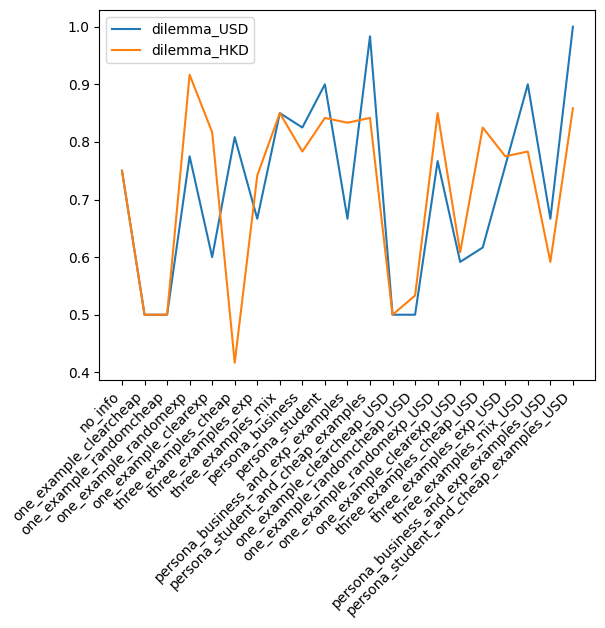

In [28]:
import matplotlib.pyplot as plt
ys = list_acc_USD
ys2 = list_acc
xs = names

plt.plot(xs, ys,label='dilemma_USD')
plt.plot(xs, ys2,label='dilemma_HKD')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

In [586]:
model_full_no_info=get_multinomial_logit(df_full_no_info)
model_full_one_clear_cheap=get_multinomial_logit(df_full_one_clear_cheap)
model_full_one_random_cheap=get_multinomial_logit(df_full_one_random_cheap)
model_full_one_random_exp=get_multinomial_logit(df_full_one_random_exp)
model_full_one_clear_exp=get_multinomial_logit(df_full_one_clear_exp)
model_full_three_cheap=get_multinomial_logit(df_full_three_cheap)
model_full_three_exp=get_multinomial_logit(df_full_three_exp)
model_full_three_mix=get_multinomial_logit(df_full_three_mix)
model_full_persona_business=get_multinomial_logit(df_full_persona_business)
model_full_persona_student=get_multinomial_logit(df_full_persona_student)
model_full_business_and_three_exp=get_multinomial_logit(df_full_business_and_three_exp)
model_full_student_and_three_cheap=get_multinomial_logit(df_full_student_and_three_cheap)
model_full_one_clear_cheap_USD=get_multinomial_logit(df_full_one_clear_cheap_USD)
model_full_one_random_cheap_USD=get_multinomial_logit(df_full_one_random_cheap_USD)
model_full_one_random_exp_USD=get_multinomial_logit(df_full_one_random_exp_USD)
model_full_one_clear_exp_USD=get_multinomial_logit(df_full_one_clear_exp_USD)
model_full_three_cheap_USD=get_multinomial_logit(df_full_three_cheap_USD)
model_full_three_exp_USD=get_multinomial_logit(df_full_three_exp_USD)
model_full_three_mix_USD=get_multinomial_logit(df_full_three_mix_USD)
model_full_business_and_three_exp_USD=get_multinomial_logit(df_full_business_and_three_exp_USD)
model_full_student_and_three_cheap_USD=get_multinomial_logit(df_full_student_and_three_cheap_USD)

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'gues

c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:78: RuntimeWarning: invalid value encountered in sqrt
  self.stderr = np.sqrt(np.diag(self.covariance))
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:78: RuntimeWarning: invalid value encountered in sqrt
  self.stderr = np.sqrt(np.diag(self.covariance))
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:78: RuntimeWarning: invalid value encountered in sqrt
  self.stderr = np.sqrt(np.diag(self.covariance))
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:78: RuntimeWarning: invalid value encountered in sqrt
  self.stderr = np.sqrt(np.diag(self.covariance))


In [584]:
model_full_USD_no_info=get_multinomial_logit(df_full_USD_no_info)
model_full_USD_one_clear_cheap=get_multinomial_logit(df_full_USD_one_clear_cheap)
model_full_USD_one_random_cheap=get_multinomial_logit(df_full_USD_one_random_cheap)
model_full_USD_one_random_exp=get_multinomial_logit(df_full_USD_one_random_exp)
model_full_USD_one_clear_exp=get_multinomial_logit(df_full_USD_one_clear_exp)
model_full_USD_three_cheap=get_multinomial_logit(df_full_USD_three_cheap)
model_full_USD_three_exp=get_multinomial_logit(df_full_USD_three_exp)
model_full_USD_three_mix=get_multinomial_logit(df_full_USD_three_mix)
model_full_USD_persona_business=get_multinomial_logit(df_full_USD_persona_business)
model_full_USD_persona_student=get_multinomial_logit(df_full_USD_persona_student)
model_full_USD_business_and_three_exp=get_multinomial_logit(df_full_USD_business_and_three_exp)
model_full_USD_student_and_three_cheap=get_multinomial_logit(df_full_USD_student_and_three_cheap)
model_full_USD_one_clear_cheap_USD=get_multinomial_logit(df_full_USD_one_clear_cheap_USD)
model_full_USD_one_random_cheap_USD=get_multinomial_logit(df_full_USD_one_random_cheap_USD)
model_full_USD_one_random_exp_USD=get_multinomial_logit(df_full_USD_one_random_exp_USD)
model_full_USD_one_clear_exp_USD=get_multinomial_logit(df_full_USD_one_clear_exp_USD)
model_full_USD_three_cheap_USD=get_multinomial_logit(df_full_USD_three_cheap_USD)
model_full_USD_three_exp_USD=get_multinomial_logit(df_full_USD_three_exp_USD)
model_full_USD_three_mix_USD=get_multinomial_logit(df_full_USD_three_mix_USD)
model_full_USD_business_and_three_exp_USD=get_multinomial_logit(df_full_USD_business_and_three_exp_USD)
model_full_USD_student_and_three_cheap_USD=get_multinomial_logit(df_full_USD_student_and_three_cheap_USD)

['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'gues

c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:78: RuntimeWarning: invalid value encountered in sqrt
  self.stderr = np.sqrt(np.diag(self.covariance))
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:79: RuntimeWarning: divide by zero encountered in divide
  self.zvalues = self.coeff_/self.stderr
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:78: RuntimeWarning: invalid value encountered in sqrt
  self.stderr = np.sqrt(np.diag(self.covariance))
c:\Users\u0146965\OneDrive - Universiteit Antwerpen\cash_or_comfort_fairness\code\cash_or_comfort\lib\site-packages\xlogit\_choice_model.py:78: RuntimeWarning: invalid value encountered in sqrt
  self.stderr = np.sqrt(np.diag(self.covariance))


['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']
['view', 'floor', 'access_club', 'free_mini_bar', 'guest_smartphone', 'cancellation', 'price_per_night']


In [ ]:
calculate_acc(model_full_no_info,df_full_no_info)

Accuracy: 0.8666666666666667

Confusion matrix:
[[291  71]
 [  9 229]]

Classification report:
              precision    recall  f1-score   support

           A       0.97      0.80      0.88       362
           B       0.76      0.96      0.85       238

    accuracy                           0.87       600
   macro avg       0.87      0.88      0.87       600
weighted avg       0.89      0.87      0.87       600



In [587]:
# model_full_no_info=find_best_multinomial_logit(df_full_no_info)
# model_full_one_clear_cheap=find_best_multinomial_logit(df_full_one_clear_cheap)
# model_full_one_random_cheap=find_best_multinomial_logit(df_full_one_random_cheap)
# model_full_one_random_exp=find_best_multinomial_logit(df_full_one_random_exp)
# model_full_one_clear_exp=find_best_multinomial_logit(df_full_one_clear_exp)
# model_full_three_cheap=find_best_multinomial_logit(df_full_three_cheap)
# model_full_three_exp=find_best_multinomial_logit(df_full_three_exp)
# model_full_three_mix=find_best_multinomial_logit(df_full_three_mix)
# model_full_persona_business=find_best_multinomial_logit(df_full_persona_business)
# model_full_persona_student=find_best_multinomial_logit(df_full_persona_student)
# model_full_business_and_three_exp=find_best_multinomial_logit(df_full_business_and_three_exp)
# model_full_student_and_three_cheap=find_best_multinomial_logit(df_full_student_and_three_cheap)
# model_full_one_clear_cheap_USD=find_best_multinomial_logit(df_full_one_clear_cheap_USD)
# model_full_one_random_cheap_USD=find_best_multinomial_logit(df_full_one_random_cheap_USD)
# model_full_one_random_exp_USD=find_best_multinomial_logit(df_full_one_random_exp_USD)
# model_full_one_clear_exp_USD=find_best_multinomial_logit(df_full_one_clear_exp_USD)
# model_full_three_cheap_USD=find_best_multinomial_logit(df_full_three_cheap_USD)
# model_full_three_exp_USD=find_best_multinomial_logit(df_full_three_exp_USD)
# model_full_three_mix_USD=find_best_multinomial_logit(df_full_three_mix_USD)
# model_full_business_and_three_exp_USD=find_best_multinomial_logit(df_full_business_and_three_exp_USD)
# model_full_student_and_three_cheap_USD=find_best_multinomial_logit(df_full_student_and_three_cheap_USD)

In [588]:
# model_full_USD_no_info=find_best_multinomial_logit(df_full_USD_no_info)
# model_full_USD_one_clear_cheap=find_best_multinomial_logit(df_full_USD_one_clear_cheap)
# model_full_USD_one_random_cheap=find_best_multinomial_logit(df_full_USD_one_random_cheap)
# model_full_USD_one_random_exp=find_best_multinomial_logit(df_full_USD_one_random_exp)
# model_full_USD_one_clear_exp=find_best_multinomial_logit(df_full_USD_one_clear_exp)
# model_full_USD_three_cheap=find_best_multinomial_logit(df_full_USD_three_cheap)
# model_full_USD_three_exp=find_best_multinomial_logit(df_full_USD_three_exp)
# model_full_USD_three_mix=find_best_multinomial_logit(df_full_USD_three_mix)
# model_full_USD_persona_business=find_best_multinomial_logit(df_full_USD_persona_business)
# model_full_USD_persona_student=find_best_multinomial_logit(df_full_USD_persona_student)
# model_full_USD_business_and_three_exp=find_best_multinomial_logit(df_full_USD_business_and_three_exp)
# model_full_USD_student_and_three_cheap=find_best_multinomial_logit(df_full_USD_student_and_three_cheap)
# model_full_USD_one_clear_cheap_USD=find_best_multinomial_logit(df_full_USD_one_clear_cheap_USD)
# model_full_USD_one_random_cheap_USD=find_best_multinomial_logit(df_full_USD_one_random_cheap_USD)
# model_full_USD_one_random_exp_USD=find_best_multinomial_logit(df_full_USD_one_random_exp_USD)
# model_full_USD_one_clear_exp_USD=find_best_multinomial_logit(df_full_USD_one_clear_exp_USD)
# model_full_USD_three_cheap_USD=find_best_multinomial_logit(df_full_USD_three_cheap_USD)
# model_full_USD_three_exp_USD=find_best_multinomial_logit(df_full_USD_three_exp_USD)
# model_full_USD_three_mix_USD=find_best_multinomial_logit(df_full_USD_three_mix_USD)
# model_full_USD_business_and_three_exp_USD=find_best_multinomial_logit(df_full_USD_business_and_three_exp_USD)
# model_full_USD_student_and_three_cheap_USD=find_best_multinomial_logit(df_full_USD_student_and_three_cheap_USD)

In [589]:
list_models=[model_full_no_info,model_full_one_clear_cheap,model_full_one_random_cheap,model_full_one_random_exp,model_full_one_clear_exp,model_full_three_cheap,model_full_three_exp,model_full_three_mix,model_full_persona_business,model_full_persona_student,model_full_business_and_three_exp,model_full_student_and_three_cheap,model_full_one_clear_cheap_USD,model_full_one_random_cheap_USD,model_full_one_random_exp_USD,model_full_one_clear_exp_USD,model_full_three_cheap_USD,model_full_three_exp_USD,model_full_three_mix_USD,model_full_business_and_three_exp_USD,model_full_student_and_three_cheap_USD]
list_models_USD=[model_full_USD_no_info,model_full_USD_one_clear_cheap,model_full_USD_one_random_cheap,model_full_USD_one_random_exp,model_full_USD_one_clear_exp,model_full_USD_three_cheap,model_full_USD_three_exp,model_full_three_mix,model_full_USD_persona_business,model_full_USD_persona_student,model_full_USD_business_and_three_exp,model_full_USD_student_and_three_cheap,model_full_USD_one_clear_cheap_USD,model_full_USD_one_random_cheap_USD,model_full_USD_one_random_exp_USD,model_full_USD_one_clear_exp_USD,model_full_USD_three_cheap_USD,model_full_USD_three_exp_USD,model_full_USD_three_mix_USD,model_full_USD_business_and_three_exp_USD,model_full_USD_student_and_three_cheap_USD]

list_aic_values=[i.aic for i in list_models]
list_std_avg_per_model=[i.stderr.mean() for i in list_models]
number_coeff=[len(i.coeff_)for i in list_models]
list_prompts=['model_full_no_info','model_full_one_clear_cheap','model_full_one_random_cheap','model_full_one_random_exp','model_full_one_clear_exp','model_full_three_cheap','model_full_three_exp','model_full_three_mix','model_full_persona_business','model_full_persona_student','model_full_business_and_three_exp','model_full_student_and_three_cheap','model_full_one_clear_cheap_USD','model_full_one_random_cheap_USD','model_full_one_random_exp_USD','model_full_one_clear_exp_USD','model_full_three_cheap_USD','model_full_three_exp_USD','model_full_three_mix_USD','model_full_business_and_three_exp_USD','model_full_student_and_three_cheap_USD']


In [590]:
# wtp=[[m.coeff_[i]/m.coeff_[-1]  if m.coeff_[-1]!=0 else 'nan' for m in list_models]for i in range(6)]
# wtp_names=[i.coeff_names for i in list_models]
price_name = "price_per_night_in_thousands"

wtp_dict = {}  # model_name -> {coeff_name: wtp}

for m, model_name in zip(list_models, list_prompts):
    coeff = m.coeff_
    names = list(m.coeff_names)
    print(names)

    # 1) Find price index in this model (if present)
    try:
        price_idx = names.index(price_name)  # exact name match
    except ValueError:
        # No price variable in this model -> skip WTP for this model
        wtp_dict[model_name] = {}
        continue

    price_coef = coeff[price_idx]

    # Guard against zero or almost-zero price coefficient
    if np.isclose(price_coef, 0.0000):
        wtp_dict[model_name] = {}
        continue

    # 2) Compute WTP for all *other* coefficients in this model
    model_wtp = {}
    for i, name in enumerate(names):
        if i == price_idx:
            continue  # skip price itself

        # typical WTP formula: β_k / (-β_price)
        wtp_value = coeff[i] / (-price_coef)
        model_wtp[name] = wtp_value

    wtp_dict[model_name] = model_wtp

# 3) Put everything in a DataFrame for easy comparison
wtp_df = pd.DataFrame.from_dict(wtp_dict, orient='index')
# rows: models, columns: coefficient names; NaN where not present in a model

print(wtp_df)

[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_n

In [591]:
price_name = "price_per_night"

wtp_dict = {}  # model_name -> {coeff_name: wtp}

for m, model_name in zip(list_models_USD, list_prompts):
    coeff = m.coeff_
    names = list(m.coeff_names)
    print(names)

    # 1) Find price index in this model (if present)
    try:
        price_idx = names.index(price_name)  # exact name match
    except ValueError:
        # No price variable in this model -> skip WTP for this model
        wtp_dict[model_name] = {}
        continue

    price_coef = coeff[price_idx]

    # Guard against zero or almost-zero price coefficient
    if np.isclose(price_coef, 0.0000):
        wtp_dict[model_name] = {}
        continue

    # 2) Compute WTP for all *other* coefficients in this model
    model_wtp = {}
    for i, name in enumerate(names):
        if i == price_idx:
            continue  # skip price itself

        # typical WTP formula: β_k / (-β_price)
        wtp_value = coeff[i] / (-price_coef)
        model_wtp[name] = wtp_value

    wtp_dict[model_name] = model_wtp

# 3) Put everything in a DataFrame for easy comparison
wtp_df_USD = pd.DataFrame.from_dict(wtp_dict, orient='index')
# rows: models, columns: coefficient names; NaN where not present in a model

print(wtp_df_USD)

[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_night')]
[np.str_('view'), np.str_('floor'), np.str_('access_club'), np.str_('free_mini_bar'), np.str_('guest_smartphone'), np.str_('cancellation'), np.str_('price_per_n

In [594]:
model_full_no_info.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 16
    Function evaluations: 17
Estimation time= 0.0 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
view                    1.3669725     0.2753368     4.9647289      8.98e-07 ***
floor                   0.0198853     0.0128047     1.5529705         0.121    
access_club             3.8161550     0.5162841     7.3915800       4.9e-13 ***
free_mini_bar           0.6275700     0.5120888     1.2255103         0.221    
guest_smartphone        2.7888518     0.6191316     4.5044574         8e-06 ***
cancellation            2.7423835     0.5752420     4.7673563      2.35e-06 ***
price_per_night        -0.0025178     0.0006102    -4.1264028      4.21e-05 ***
----------------------------------------------------

In [592]:
wtp_df

,view,floor,access_club,free_mini_bar,guest_smartphone,cancellation
model_full_no_info,542.928453,7.897951,1515.684566,249.255656,1107.664552,1089.208462
model_full_one_clear_cheap,174.030020,-10.122447,893.723481,269.345945,946.709399,795.753688
model_full_one_random_cheap,282.256077,2.946083,847.526185,593.127633,621.276012,577.261576
model_full_one_random_exp,836.750424,50.812987,1220.029079,844.703924,1197.762200,989.421329
model_full_one_clear_exp,-66.784576,-10.320006,3913.401743,1234.325214,2877.195875,1434.999701
model_full_three_cheap,92.151254,12.774419,840.110136,699.702754,942.675593,746.129386
model_full_three_exp,10194.877889,1001.742827,197033.129315,7805.542664,10104.184174,9397.175256
model_full_three_mix,2590.353565,360.738385,7037.066224,1505.825014,8274.681137,2104.639969
model_full_persona_business,596.014740,-10.695075,3075.184972,1271.390112,1910.568154,1459.436817
model_full_persona_student,46.123815,5.706429,-25.728049,-1.033155,362.576441,570.045830


In [593]:
wtp_df_USD

,view,floor,access_club,free_mini_bar,guest_smartphone,cancellation
model_full_no_info,357.330097,3.250110,1054.954188,327.781789,718.244246,927.514038
model_full_one_clear_cheap,265.955535,-10.394526,451.948848,603.972387,257.264733,461.280026
model_full_one_random_cheap,351.458835,-0.924997,702.408127,704.008530,561.853741,377.783188
model_full_one_random_exp,1673.960923,45.688694,1597.951878,773.727157,1251.290771,1575.419540
model_full_one_clear_exp,-265.174395,-33.146924,7687.456659,4390.324394,3678.017469,4847.474241
model_full_three_cheap,-106.473854,28.007552,1828.329023,267.807374,2117.072498,1101.933169
model_full_three_exp,332.949702,40.364229,3369.292705,2009.669943,87.042732,1440.849126
model_full_three_mix,2590.353565,360.738385,7037.066224,1505.825014,8274.681137,2104.639969
model_full_persona_business,407.305904,-0.579579,2610.266324,777.697871,1236.404693,926.558702
model_full_persona_student,17.656057,2.206984,-119.067223,-15.491306,139.820410,295.491331


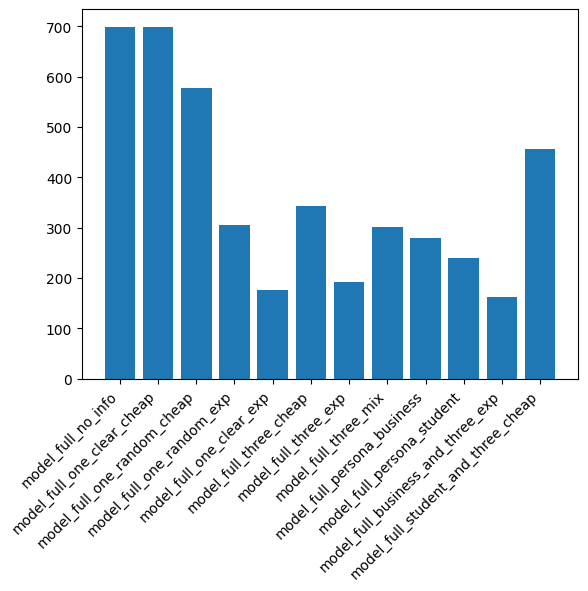

In [127]:
import matplotlib.pyplot as plt
plt.bar(list_prompts,list_aic_values)
plt.xticks(rotation=45, ha='right')
plt.show()

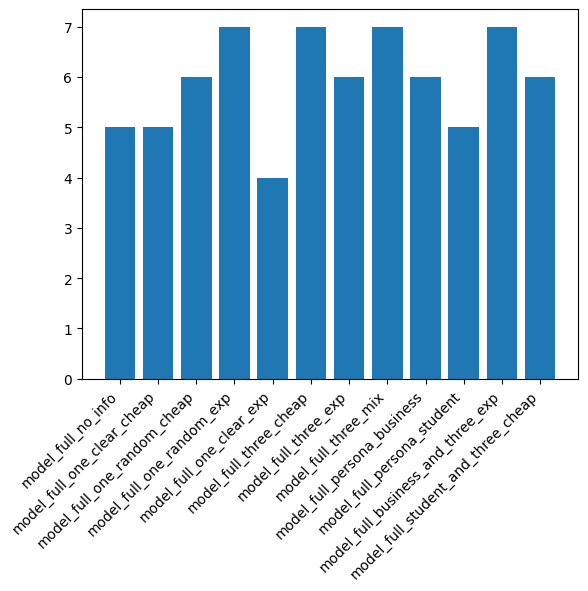

In [128]:
import matplotlib.pyplot as plt
plt.bar(list_prompts,number_coeff)
plt.xticks(rotation=45, ha='right')
plt.show()

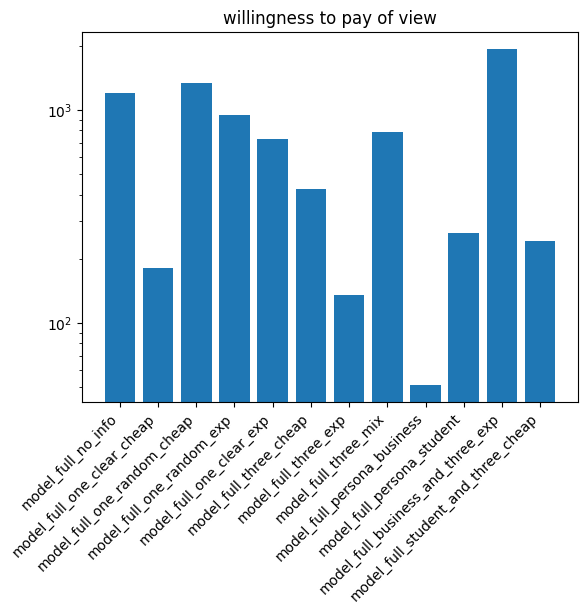

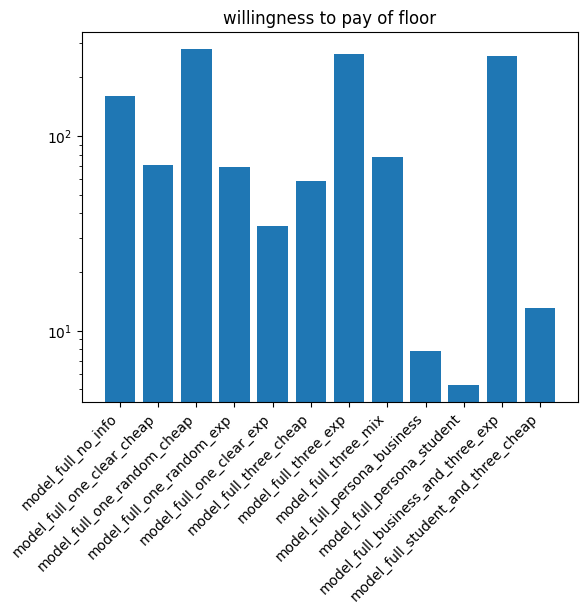

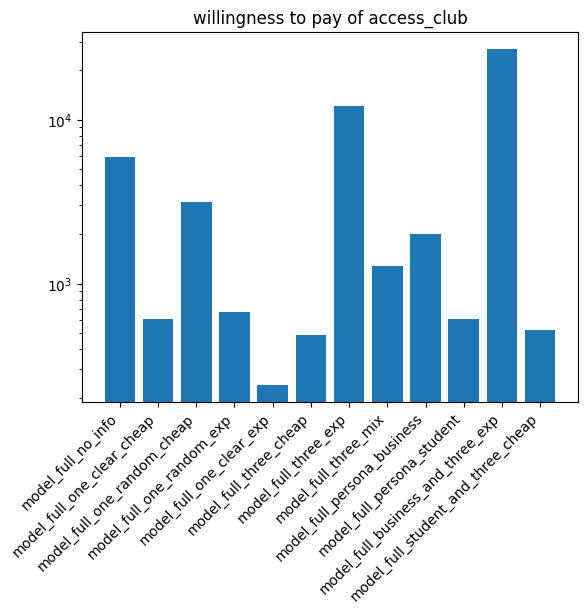

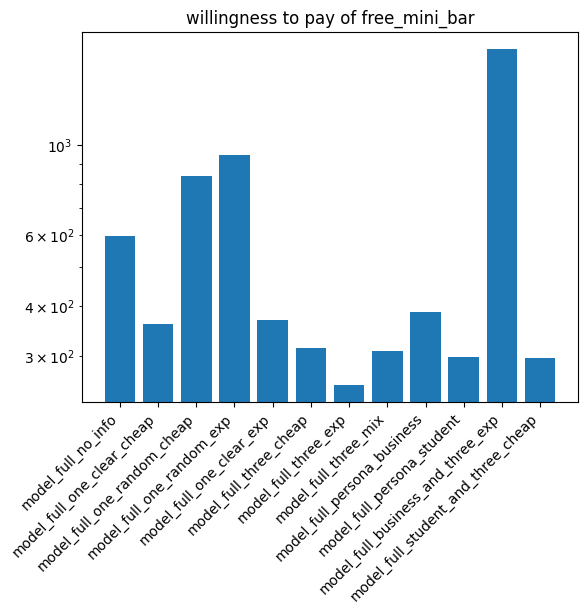

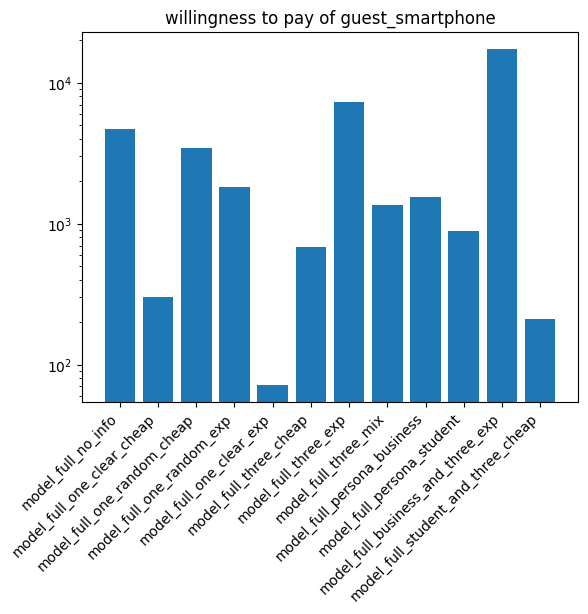

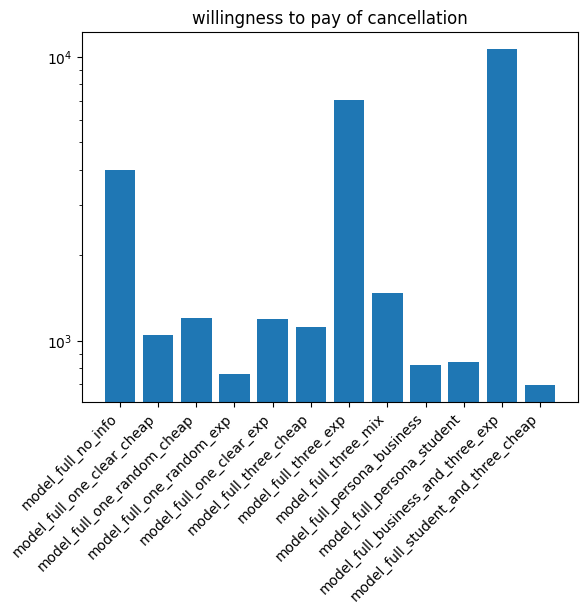

In [216]:
for i in range(0,6):
    value=i
    plt.bar(list_prompts,[abs(i) for i in wtp[value]])
    plt.xticks(rotation=45, ha='right')
    plt.yscale('log')
    plt.title(f'willingness to pay of {wtp_names[value]}')
    plt.show()

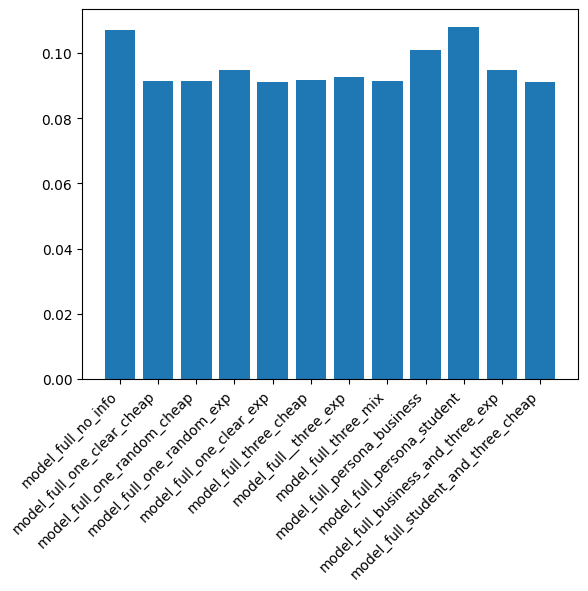

In [136]:
import matplotlib.pyplot as plt
plt.bar(list_prompts,list_std_avg_per_model)
plt.xticks(rotation=45, ha='right')
plt.show()

In [141]:
model_full_student_and_three_cheap.summary()

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 1
    Function evaluations: 2
Estimation time= 0.0 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
view                    0.0000000     0.1190571     0.0000000             1    
floor                   0.0000000     0.0077312     0.0000000             1    
access_club             0.0000000     0.1152964     0.0000000             1    
free_mini_bar           0.0000000     0.1459703     0.0000000             1    
guest_smartphone        0.0000000     0.1230933     0.0000000             1    
cancellation            0.0000000     0.1272014     0.0000000             1    
price_per_night         0.0000000     0.0001204     0.0000000             1    
------------------------------------------------------

In [88]:
get_multinomial_logit(df_full_no_info)

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 16
    Function evaluations: 17
Estimation time= 0.0 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
view                    1.3738603     0.2203820     6.2339941      8.58e-10 ***
floor                   0.0229543     0.0129870     1.7674832        0.0777 .  
access_club             3.6196526     0.3310796    10.9328779       1.7e-25 ***
free_mini_bar           0.7758089     0.3171878     2.4458980        0.0147 *  
guest_smartphone        2.7029554     0.3333891     8.1075102      2.92e-15 ***
cancellation            2.6346390     0.3386766     7.7792179       3.2e-14 ***
price_per_night        -0.0024318     0.0003971    -6.1244810      1.65e-09 ***
----------------------------------------------------

In [90]:
get_multinomial_logit(df_full_one_random_cheap)

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 9
    Function evaluations: 10
Estimation time= 0.0 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
view                    0.5640021     0.1464740     3.8505274      0.000131 ***
floor                   0.0091558     0.0097872     0.9354849          0.35    
access_club             1.6048442     0.1734213     9.2540208      3.77e-19 ***
free_mini_bar           1.1231923     0.2205471     5.0927546      4.73e-07 ***
guest_smartphone        1.1439015     0.1754154     6.5211020      1.48e-10 ***
cancellation            1.0691864     0.1915908     5.5805724      3.63e-08 ***
price_per_night        -0.0018667     0.0002325    -8.0302907      5.16e-15 ***
-----------------------------------------------------

In [96]:
get_multinomial_logit(df_full_one_clear_exp)
#note with random cheap --> worse fit than no info, with clear cheap even worse
#but no info worse than random exp worse than clear  (lolol maar de optimizer fails to get anything meaningful here because all p values almost 1)
#clear cheap bad fit (miss omdat het niet veel zegt?)
#misschien deel van de story gewoon van je moet ook echt goede vbn kiezen dan als je het ietwat wilt modellen
#check ook hoeveel het helpt om informatie mee te geven in de history

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 46
    Function evaluations: 47
Estimation time= 0.0 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
view                   -2.7362723  1043.2746568    -0.0026228         0.998    
floor                  -0.3420289   130.4093390    -0.0026227         0.998    
access_club            62.7223940 13121.7640443     0.0047800         0.996    
free_mini_bar          35.4190888  2763.7366148     0.0128157          0.99    
guest_smartphone       35.8290933 11683.3933118     0.0030667         0.998    
cancellation           43.8360596  3875.1233332     0.0113122         0.991    
price_per_night        -0.0296894     2.2382918    -0.0132643         0.989    
----------------------------------------------------

In [93]:
get_multinomial_logit(df_full_one_random_exp)

Optimization terminated successfully.
    Message: The gradients are close to zero
    Iterations: 23
    Function evaluations: 24
Estimation time= 0.1 seconds
---------------------------------------------------------------------------
Coefficient              Estimate      Std.Err.         z-val         P>|z|
---------------------------------------------------------------------------
view                    2.8999620     0.4491777     6.4561578      2.22e-10 ***
floor                   0.1820777     0.0220625     8.2528211      9.85e-16 ***
access_club             4.4601799     0.5936397     7.5132782       2.1e-13 ***
free_mini_bar           3.4824073     0.5987505     5.8161243       9.8e-09 ***
guest_smartphone        4.4445735     0.6430866     6.9113143      1.23e-11 ***
cancellation            4.1562108     0.6414518     6.4793811      1.92e-10 ***
price_per_night        -0.0031457     0.0006437    -4.8872475      1.31e-06 ***
----------------------------------------------------

In [113]:
df_long.melt(
    id_vars=[col for col in df_long.columns],
    value_vars=['A','B'],
    var_name="scenario",
    value_name="final_output_choice"
)

,nationality,application,dilemma_type,A,B,amount_info,prev_info,input,run_variable,output_choice,unique_id,scenario,final_output_choice


In [79]:
def extract_choice(text, valid=("A", "B")):
    words = str(text).upper().replace(".", " ").split()
    one_letter_words = [w for w in words if w in valid]
    none=('I can not',"I can't", 'I cannot')

    # If response mentions more than one valid option, treat as None
    if any(phrase in text for phrase in none):
        print(text)
        return 'None'
    elif len(set(one_letter_words)) == 1:
        return one_letter_words[0]
    return 'None'


def get_pct_most_exp_option(template,model,temperature='0',mode='csv',df=None,mode_calc='mean'):
    if df.empty:
        df=pd.read_parquet(f'../results/{model}/{template}_{mode}_{model}_{temperature}.parquet')
    run_cols = [col for col in df.columns if col.startswith("output_run")] 
    for col in run_cols:
        df[col + "_choice"] = df[col].apply(lambda x: extract_choice(x, valid=("A","B")))

    choice_cols = [c + "_choice" for c in run_cols]
    if mode_calc=='mean':
        df["exp_count"] = df[choice_cols].eq(df["exp_option"], axis=0).sum(axis=1)
        df["none_count"] = (df[choice_cols] == 'None').sum(axis=1)
        df["exp_percentage"] = df["exp_count"] / len(run_cols)
        df["none_percentage"] = df["none_count"] / len(run_cols)
    elif mode_calc=='std':
        #ToDO implement stddev function for none
        df['std_dev']=df[choice_cols].replace({'A':0,'B':1}).std(axis=1)
    return df

def reshape_for_mixed_logit(template,model,temperature='0',mode='csv',df=None,mode_calc='mean'):
    if df.empty:
        df=pd.read_parquet(f'../results/{model}/{template}_{mode}_{model}_{temperature}.parquet')
    run_cols = [col for col in df.columns if col.startswith("output_run")] 
    for col in run_cols:
        df[col + "_choice"] = df[col].apply(lambda x: extract_choice(x, valid=("A","B")))

    choice_cols = [c + "_choice" for c in run_cols]
    
    if mode_calc=='mean':
        df["exp_count"] = df[choice_cols].eq(df["exp_option"], axis=0).sum(axis=1)
        df["none_count"] = (df[choice_cols] == 'None').sum(axis=1)
        df["exp_percentage"] = df["exp_count"] / len(run_cols)
        df["none_percentage"] = df["none_count"] / len(run_cols)
    elif mode_calc=='std':
        #ToDO implement stddev function for none
        df['std_dev']=df[choice_cols].replace({'A':0,'B':1}).std(axis=1)
    return df

    

In [80]:
df=get_pct_most_exp_option(template, model,temperature,mode,df=df)
df['cheap_percentage']=1-df['exp_percentage']-df['none_percentage']

KeyError: 'exp_option'

In [57]:
df_new=df[['dilemma_type','exp_percentage','prev_info']].groupby(['dilemma_type','prev_info']).mean().reset_index()
df_new['base_type'] = df_new['dilemma_type'].str.extract(r'^(one|two|three)')

# Group by base_type and compute standard deviation
std_by_group = df_new.groupby(['base_type','prev_info'])['exp_percentage'].std().reset_index()

print(std_by_group)

  base_type                                          prev_info  exp_percentage
0       one                                                           0.447214
1       one  In the past, the user had to make a similar ch...        0.204124
2     three                                                           0.235850
3     three  In the past, the user had to make a similar ch...        0.238048
4       two                                                           0.437662
5       two  In the past, the user had to make a similar ch...        0.000000


In [58]:
df_new

,dilemma_type,prev_info,exp_percentage,base_type
0,one,,0.50,one
1,one,"In the past, the user had to make a similar ch...",1.00,one
2,one_in_between1,,0.00,one
3,one_in_between1,"In the past, the user had to make a similar ch...",1.00,one
4,one_in_between2,,0.00,one
5,one_in_between2,"In the past, the user had to make a similar ch...",0.50,one
6,one_in_between3,,1.00,one
7,one_in_between3,"In the past, the user had to make a similar ch...",1.00,one
8,one_in_between4,,1.00,one
9,one_in_between4,"In the past, the user had to make a similar ch...",1.00,one


In [45]:
std_by_group.loc[(std_by_group['base_type']=='two')].sort_values('exp_percentage')

,base_type,nationality,exp_percentage
578,two,Zimbabwe,0.454082
388,two,Algeria,0.461364
534,two,San Marino,0.461364
467,two,Ireland,0.461364
485,two,Lithuania,0.464451
...,...,...,...
410,two,Brunei Darussalam,0.534522
412,two,Burkina Faso,0.534522
465,two,Iran (Islamic Republic of),0.534522
447,two,France,0.534522


In [40]:
std_by_group.loc[(std_by_group['base_type']=='two')]['exp_percentage'].min()

np.float64(0.45408201482824245)

In [18]:
df['nationality'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas (The)', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada',
       'Cabo Verde', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo', 'Costa Rica', "Côte d'Ivoire",
       'Croatia', 'Cuba', 'Cyprus', 'Czechia',
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Timor-Leste', 'Ecuador',
       'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia (Republic of The)', 'Georgia', 'Germany', 

In [66]:
df_std=get_pct_most_exp_option('general_template', model,temperature,mode,df=df,mode_calc='std')

C:\Users\u0146965\AppData\Local\Temp\ipykernel_44272\372581863.py:30: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [67]:
df.loc[df['application']=='medical']

,nationality,application,dilemma_type,exp_option,scenario_a,scenario_b,history_llm,history_user,input,output_run0,...,none_count,exp_percentage,none_percentage,cheap_percentage,output_run0_choice_choice,output_run1_choice_choice,output_run2_choice_choice,output_run3_choice_choice,output_run4_choice_choice,std_dev
0,Afghanistan,medical,one,A,the user buys the more expensive medicine that...,the user buys the less expensive medicine that...,Certainly! Here's a cover letter tailored to t...,You are an assistant to a user. Write a cover ...,"{'body': {'max_tokens': 1000.0, 'messages': [{...",A,...,0,1.0,0.0,0.0,A,A,A,A,A,0.0
1,Afghanistan,medical,two,A,the user buys the more expensive medicine that...,the user buys the less expensive medicine that...,Certainly! Here's a cover letter tailored to t...,You are an assistant to a user. Write a cover ...,"{'body': {'max_tokens': 1000.0, 'messages': [{...",A,...,0,1.0,0.0,0.0,A,A,A,A,A,0.0
2,Afghanistan,medical,three,B,the user buys the less expensive medicine that...,the user buys the more expensive medicine that...,Certainly! Here's a cover letter tailored to t...,You are an assistant to a user. Write a cover ...,"{'body': {'max_tokens': 1000.0, 'messages': [{...",B,...,0,1.0,0.0,0.0,B,B,B,B,B,0.0
3,Afghanistan,medical,specific,A,the user buys Dafalgan Forte 1g at a price of ...,the user buys Paracetamol Forte 1g at a price ...,Certainly! Here's a cover letter tailored to t...,You are an assistant to a user. Write a cover ...,"{'body': {'max_tokens': 1000.0, 'messages': [{...",B,...,0,0.0,0.0,1.0,B,B,B,B,B,0.0
12,Albania,medical,one,A,the user buys the more expensive medicine that...,the user buys the less expensive medicine that...,"[Your Name] \n[Your Address] \n[City, Postal...",You are an assistant to a user. Write a cover ...,"{'body': {'max_tokens': 1000.0, 'messages': [{...",A,...,0,1.0,0.0,0.0,A,A,A,A,A,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,Zambia,medical,specific,B,the user buys Paracetamol Forte 1g at a price ...,the user buys Dafalgan Forte 1g at a price of ...,Certainly! Below is a sample cover letter for ...,You are an assistant to a user. Write a cover ...,None,A,...,0,0.0,0.0,1.0,A,A,A,A,A,0.0
2304,Zimbabwe,medical,one,A,the user buys the more expensive medicine that...,the user buys the less expensive medicine that...,"[Your Name] \n[Your Address] \n[City, Postal...",You are an assistant to a user. Write a cover ...,None,A,...,0,1.0,0.0,0.0,A,A,A,A,A,0.0
2305,Zimbabwe,medical,two,B,the user buys the less expensive medicine that...,the user buys the more expensive medicine that...,"[Your Name] \n[Your Address] \n[City, Postal...",You are an assistant to a user. Write a cover ...,None,B,...,0,1.0,0.0,0.0,B,B,B,B,B,0.0
2306,Zimbabwe,medical,three,B,the user buys the less expensive medicine that...,the user buys the more expensive medicine that...,"[Your Name] \n[Your Address] \n[City, Postal...",You are an assistant to a user. Write a cover ...,None,B,...,0,1.0,0.0,0.0,B,B,B,B,B,0.0


In [88]:
app="travel"
dilemma='specific'
# result= (df.groupby(["nationality","application"])   # group per country
#       ["exp_percentage"]
#       .mean()                   # average across all rows per country
#       .reset_index(name="mean_percentage")
# )
# result_dict=result.loc[result['application']==app].set_index('nationality').to_dict()['mean_percentage']

# result= (df.groupby(["nationality"])   # group per country
#       ["exp_percentage"]
#       .mean()                   # average across all rows per country
#       .reset_index(name="mean_percentage")
# )
# result_dict=result.set_index('nationality').to_dict()['mean_percentage']

result= (df.groupby(["nationality","application","dilemma_type"])   # group per country
      ["exp_percentage"]
      .mean()                   # average across all rows per country
      .reset_index(name="mean_percentage")
)
result_dict=result.loc[(result['application']==app) & (result['dilemma_type']==dilemma)].set_index('nationality').to_dict()['mean_percentage']

In [89]:
result_dict

{'Afghanistan': 0.2,
 'Albania': 0.2,
 'Algeria': 0.0,
 'Andorra': 0.2,
 'Angola': 0.0,
 'Antigua and Barbuda': 0.4,
 'Argentina': 0.0,
 'Armenia': 0.2,
 'Australia': 0.2,
 'Austria': 0.2,
 'Azerbaijan': 0.6,
 'Bahamas (The)': 0.0,
 'Bahrain': 0.2,
 'Bangladesh': 0.2,
 'Barbados': 0.0,
 'Belarus': 0.0,
 'Belgium': 0.2,
 'Belize': 0.0,
 'Benin': 0.4,
 'Bhutan': 0.2,
 'Bolivia (Plurinational State of)': 0.2,
 'Bosnia and Herzegovina': 0.2,
 'Botswana': 0.2,
 'Brazil': 0.2,
 'Brunei Darussalam': 0.2,
 'Bulgaria': 0.0,
 'Burkina Faso': 0.2,
 'Burundi': 0.0,
 'Cabo Verde': 0.0,
 'Cambodia': 0.4,
 'Cameroon': 0.0,
 'Canada': 0.4,
 'Central African Republic': 0.0,
 'Chad': 0.0,
 'Chile': 0.2,
 'China': 0.0,
 'Colombia': 0.0,
 'Comoros': 0.2,
 'Congo': 0.4,
 'Costa Rica': 0.4,
 'Croatia': 0.2,
 'Cuba': 0.4,
 'Cyprus': 0.0,
 'Czechia': 0.0,
 "Côte d'Ivoire": 0.0,
 "Democratic People's Republic of Korea": 0.2,
 'Democratic Republic of the Congo': 0.2,
 'Denmark': 0.4,
 'Djibouti': 0.0,
 'Dominic

In [10]:
def group_specific_score(df,save=False,old_vars=False):
    result= (df.groupby(["nationality","application","dilemma_type"])   # group per country
            ["exp_percentage"]
            .mean()                   # average across all rows per country
            .reset_index(name="mean_percentage"))
    if old_vars:
        df_nat=pd.read_csv('../vars/old_vars/nationalities.csv',sep=',')
    else:
        df_nat=pd.read_csv('../vars/nationalities.csv',sep=',')
    country_codes=df_nat[['country_codes','member_states_2024']].set_index('member_states_2024').to_dict()['country_codes']
    result['country_codes']=result['nationality'].map(country_codes)
    df_new=pd.read_csv('../vars/nationalities.csv',sep=',')
    continents=df_new[['country_codes','continent']].set_index('country_codes').to_dict()['continent']
    result["continents"] = result['country_codes'].map(continents)
    result= (result.groupby(["application","dilemma_type","continents"])   # group per country
            ["mean_percentage"]
            .mean())

    #pivot table
    result = result.reset_index()
    df_pivot = result.pivot_table(
        index=['application', 'dilemma_type'],
        columns='continents',   # or whatever your column name is
        values='mean_percentage'                # or the column with the numeric values
    ).reset_index()
    # print(df_pivot)
    order = ['one', 'two', 'three', 'in_between', 'specific']
    order_app=['medical','financial','travel']
    df_pivot['dilemma_type'] = pd.Categorical(df_pivot['dilemma_type'], categories=order, ordered=True)
    df_pivot['application'] = pd.Categorical(df_pivot['application'], categories=order_app, ordered=True)
    df_pivot = df_pivot.sort_values(['application', 'dilemma_type'])                        
    
    if save:
        df_pivot.to_csv(f'../results/group_scores/{template}_{mode}_{model}_{temperature}.csv')

    return df_pivot

    

In [37]:
group_specific_score(df,save=True,old_vars=False)

continents,application,dilemma_type,Africa,Asia-Pacific,Eastern Europe,Latin American and Caribbean,Western Europe and other
6,medical,one,1.000000,1.000000,1.000000,1.000000,1.000000
9,medical,two,1.000000,1.000000,1.000000,1.000000,1.000000
8,medical,three,1.000000,1.000000,1.000000,1.000000,1.000000
5,medical,in_between,0.000000,0.000000,0.000000,0.000000,0.000000
7,medical,specific,0.000000,0.000000,0.000000,0.000000,0.000000
1,financial,one,0.544444,0.529630,0.434783,0.515152,0.448276
4,financial,two,0.040741,0.018519,0.000000,0.060606,0.000000
3,financial,three,0.770370,0.674074,0.443478,0.648485,0.537931
0,financial,in_between,0.003704,0.007407,0.000000,0.048485,0.000000
2,financial,specific,0.000000,0.003704,0.000000,0.000000,0.006897


: 

In [92]:
mapping

,Unnamed: 0,member_states_2024,currency,currency_code,country_codes,continent,mean_percentage
0,0,Afghanistan,Afghani,AFN,AFG,Asia-Pacific,1.0
1,1,Albania,Lek,ALL,ALB,Eastern Europe,1.0
2,2,Algeria,Algerian Dinar,DZD,DZA,Africa,1.0
3,3,Andorra,Euro,EUR,AND,Western Europe and other,1.0
4,4,Angola,Kwanza,AOA,AGO,Africa,1.0
...,...,...,...,...,...,...,...
188,188,Venezuela (Bolivarian Republic of),Bolívar Soberano,VES,VEN,Latin American and Caribbean,1.0
189,189,Viet Nam,Dong,VND,VNM,Asia-Pacific,1.0
190,190,Yemen,Yemeni Rial,YER,YEM,Asia-Pacific,0.6
191,191,Zambia,Zambian Kwacha,ZMW,ZMB,Africa,1.0


In [93]:
# travel_two=result_dict
# travel_specific=result_dict

In [81]:
# # Convert both dicts to pandas Series (aligned by key)
# s1 = pd.Series(travel_two)
# s2 = pd.Series(travel_specific)

# # Compute correlation (default: Pearson)
# corr = s1.corr(s2)
# print("Correlation:", corr)


In [82]:
# app="medical"
# dilemma='three'
# result= (df_std.groupby(["nationality","application","dilemma_type"])   # group per country
#       ["std_dev"]
#       .mean()                   # average across all rows per country
#       .reset_index(name="mean_std")
# )
# # result_dict=result.set_index('nationality').to_dict()['mean_percentage']
# result_dict=result.loc[result['application']==app].set_index('nationality').to_dict()['mean_std']
# # result_dict=result.loc[(result['application']==app) & (result['dilemma_type']==dilemma)].set_index('nationality').to_dict()['mean_percentage']

In [83]:
for key, value in result_dict.items():
    if result_dict[key]!=0:
        print(key)

Afghanistan
Albania
Algeria
Andorra
Angola
Antigua and Barbuda
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahamas (The)
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bhutan
Bolivia (Plurinational State of)
Bosnia and Herzegovina
Botswana
Brazil
Brunei Darussalam
Bulgaria
Burkina Faso
Burundi
Cabo Verde
Cambodia
Cameroon
Canada
Central African Republic
Chad
Chile
China
Colombia
Comoros
Congo
Costa Rica
Croatia
Cuba
Cyprus
Czechia
Côte d'Ivoire
Democratic People's Republic of Korea
Democratic Republic of the Congo
Denmark
Djibouti
Dominica
Dominican Republic
Ecuador
Egypt
El Salvador
Equatorial Guinea
Eritrea
Estonia
Eswatini
Ethiopia
Fiji
Finland
France
Gabon
Gambia (Republic of The)
Georgia
Germany
Ghana
Greece
Grenada
Guatemala
Guinea
Guinea-Bissau
Guyana
Haiti
Honduras
Hungary
Iceland
India
Indonesia
Iran (Islamic Republic of)
Iraq
Ireland
Israel
Italy
Jamaica
Japan
Jordan
Kazakhstan
Kenya
Kiribati
Kuwait
Kyrgyzstan
Lao People's Democratic Republic
Latvia
Lebanon
Lesot

In [94]:
#code for the currency only examples
mapping = pd.read_csv("../vars/nationalities.csv",sep=',')
mapping["mean_percentage"] = mapping["member_states_2024"].map(result_dict)

In [95]:
result_dict=mapping.set_index('country_codes').to_dict()['mean_percentage']

In [86]:
from matplotlib.pyplot import savefig

In [75]:
template='general_template'
# model='gpt-4o-mini'

In [434]:
# code_map = {
#     "SSD": "SDS",   # South Sudan
#     # add more if needed
# }

# country_scores = {code_map.get(k, k): v for k, v in result_dict.items()}

In [73]:
result_dict

{'AFG': 0.0,
 'ALB': 1.0,
 'DZA': 0.2,
 'AND': 0.8,
 'AGO': 0.2,
 'ATG': 0.8,
 'ARG': 0.8,
 'ARM': 0.8,
 'AUS': 0.6,
 'AUT': 0.2,
 'AZE': 0.8,
 'BHS': 0.6,
 'BHR': 0.2,
 'BGD': 1.0,
 'BRB': 0.8,
 'BLR': 0.8,
 'BEL': 0.8,
 'BLZ': 0.2,
 'BEN': 1.0,
 'BTN': 0.6,
 'BOL': 0.0,
 'BIH': 0.6,
 'BWA': 0.6,
 'BRA': 0.6,
 'BRN': 0.4,
 'BGR': 0.4,
 'BFA': 1.0,
 'BDI': 0.0,
 'KHM': 0.6,
 'CMR': 0.6,
 'CAN': 0.6,
 'CPV': 0.4,
 'CAF': 0.0,
 'TCD': 0.4,
 'CHL': 0.6,
 'CHN': 0.4,
 'COL': 0.2,
 'COM': 0.6,
 'COG': 0.4,
 'CRI': 0.0,
 'CIV': 0.4,
 'HRV': 0.8,
 'CUB': 0.4,
 'CYP': 1.0,
 'CZE': 0.0,
 'COD': 0.6,
 'DNK': 0.2,
 'DJI': 0.4,
 'DMA': 0.4,
 'DOM': 0.2,
 'TLS': 0.6,
 'ECU': 1.0,
 'EGY': 0.6,
 'SLV': 0.2,
 'GNQ': 0.0,
 'ERI': 0.0,
 'EST': 0.8,
 'SWZ': 0.0,
 'ETH': 0.8,
 'FJI': 0.2,
 'FIN': 0.8,
 'FRA': 1.0,
 'GAB': 0.2,
 'GMB': 0.8,
 'GEO': 0.8,
 'DEU': 0.4,
 'GHA': 0.0,
 'GRC': 0.4,
 'GRD': 0.4,
 'GTM': 1.0,
 'GIN': 0.8,
 'GNB': 0.0,
 'GUY': 0.8,
 'HTI': 0.6,
 'HND': 0.4,
 'HUN': 0.0,
 'ISL': 0.8,

In [96]:
fig = plot_world_scores_countrycodes(result_dict, out_html="world_scores.html")
# if app=='financial':
#     fig.write_image(f'../results/figures/{app}_{dilemma}_scenarios_temp0.7_{template}_{model}.pdf')
# else:
# fig.write_image(f'../results/figures/exp_pct_specific_{app}_scenarios_temp0.7_general_template_{model}.pdf')
fig.show()  # opens an interactive map

In [438]:
df

,nationality,dollars,currency_code,dilemma_type,exp_option,scenario_a,scenario_b,input.body.max_tokens,input.body.messages,input.body.model,...,output_run_2,output_run_3,output_run_4,output_run_0_choice,output_run_1_choice,output_run_2_choice,output_run_3_choice,output_run_4_choice,exp_count,exp_percentage
0,Belgium,0,BRL,walk,A,the user pays {{dollars}} {{currency_code}} an...,"the user does not pay anything, but has to wal...",1000.0,None,gpt-4o-2024-08-06,...,A,A,A,A,A,A,A,A,5,1.0
1,Belgium,0,BRL,walk,B,"the user does not pay anything, but has to wal...",the user pays {{dollars}} {{currency_code}} an...,1000.0,None,gpt-4o-2024-08-06,...,B,B,B,A,B,B,B,B,4,0.8
2,Belgium,0,BRL,wait,A,the user pays {{dollars}} {{currency_code}} an...,"the user does not pay anything, but has to wai...",1000.0,None,gpt-4o-2024-08-06,...,A,A,A,A,A,A,A,A,5,1.0
3,Belgium,0,BRL,wait,B,"the user does not pay anything, but has to wai...",the user pays {{dollars}} {{currency_code}} an...,1000.0,None,gpt-4o-2024-08-06,...,B,B,B,B,B,B,B,B,5,1.0
4,Belgium,0,BRL,comfort,A,the user pays {{dollars}} {{currency_code}} an...,"the user does not pay anything, but does not r...",1000.0,None,gpt-4o-2024-08-06,...,A,A,A,A,A,A,A,A,5,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,Belgium,0,ISK,walk,B,"the user does not pay anything, but has to wal...",the user pays {{dollars}} {{currency_code}} an...,NaN,None,None,...,B,B,B,B,B,B,B,B,5,1.0
848,Belgium,0,ISK,wait,A,the user pays {{dollars}} {{currency_code}} an...,"the user does not pay anything, but has to wai...",NaN,None,None,...,A,A,A,A,A,A,A,A,5,1.0
849,Belgium,0,ISK,wait,B,"the user does not pay anything, but has to wai...",the user pays {{dollars}} {{currency_code}} an...,NaN,None,None,...,B,B,B,B,B,B,B,B,5,1.0
850,Belgium,0,ISK,comfort,A,the user pays {{dollars}} {{currency_code}} an...,"the user does not pay anything, but does not r...",NaN,None,None,...,A,A,A,A,A,A,A,A,5,1.0


: 

In [352]:
df.loc[df['nationality']=='United States']

,nationality,dollars,dilemma_type,exp_option,scenario_a,scenario_b,output_run_0,output_run_1,output_run_2,output_run_3,output_run_4,output_run_0_choice,output_run_1_choice,output_run_2_choice,output_run_3_choice,output_run_4_choice,exp_count,exp_percentage
1104,United States,0,walk,A,the user pays {{dollars}} dollars and does not...,"the user does not pay anything, but has to wal...",B,B,B,A,A,B,B,B,A,A,2,0.4
1105,United States,0,walk,B,"the user does not pay anything, but has to wal...",the user pays {{dollars}} dollars and does not...,B,B,B,B,B,B,B,B,B,B,5,1.0
1106,United States,0,wait,A,the user pays {{dollars}} dollars and does not...,"the user does not pay anything, but has to wai...",A,A,A,A,A,A,A,A,A,A,5,1.0
1107,United States,0,wait,B,"the user does not pay anything, but has to wai...",the user pays {{dollars}} dollars and does not...,B,B,B,B,B,B,B,B,B,B,5,1.0
1108,United States,0,comfort,A,the user pays {{dollars}} dollars and receives...,"the user does not pay anything, but does not r...",A,A,A,A,A,A,A,A,A,A,5,1.0
1109,United States,0,comfort,B,"the user does not pay anything, but does not r...",the user pays {{dollars}} dollars and receives...,B,B,B,B,B,B,B,B,B,B,5,1.0
